# Bipolar Psychometric Item Contrasts Define Stable, Criterion-Aligned Axes in Language-Model Embedding Space

Analysis notebook for the manuscript *Bipolar psychometric item contrasts define stable, criterion-aligned axes in language-model embedding space*.

The notebook:

1. estimates four instrument-anchored axes from the 32 defining OEJTS 1.2 bipolar items;
2. parses the public OEJTS development screening table and identifies held-out items;
3. evaluates criterion alignment, convergent--discriminant structure, partial-rank diagnostics, and dominant-dichotomy classification;
4. assesses leave-one-out and bootstrap axis stability, reversed-pair antisymmetry, template sensitivity, and replication with MPNet and BGE-M3;
5. estimates parallel axes from verified generated opposition pairs; and
6. saves reusable embeddings, analysis tables, figures, and LaTeX result macros under `outputs/`.

All random procedures use fixed seeds.


## 1. Imports


In [1]:
import os
import json
import time
import warnings
import getpass
import io
import math
import re
from datetime import datetime, timezone
from itertools import combinations
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy import stats
from pydantic import BaseModel, Field

warnings.filterwarnings("default")
pd.set_option("display.max_colwidth", 200)

try:
    from IPython.display import display
except Exception:
    display = print

print("Imports ready.")


Imports ready.


## 2. Configuration


In [2]:
class CFG:
    # Embedding backends
    USE_GEMINI = True
    USE_MPNET = True
    USE_BGE = True
    GEMINI_EMB_MODEL = "gemini-embedding-2"
    MPNET_MODEL = "sentence-transformers/all-mpnet-base-v2"
    MPNET_REVISION = "e8c3b32edf5434bc2275fc9bab85f82640a19130"
    BGE_MODEL = "BAAI/bge-m3"
    BGE_REVISION = "5617a9f61b028005a4858fdac845db406aefb181"
    MPNET_PARAMETER_MILLIONS = 110
    BGE_PARAMETER_MILLIONS = 568
    EMB_TASK_INSTRUCTION = "task: sentence similarity | query: "

    # Generated-contrast arm
    RUN_LLM_PAIR_ARM = True
    GEN_MODEL = "gemini-3.5-flash"
    N_PAIRS_PER_DICHOTOMY = 40
    USE_LLM_VERIFY = True

    # Anchor embedding templates
    TEMPLATE = "A person who {anchor}."
    ALT_TEMPLATES = ["{anchor}", "Someone who typically {anchor}."]

    # Analysis settings
    SEED = 656
    N_BOOT = 2000
    N_PERM = 5000
    CI_LEVEL = 0.95
    ALPHA = 0.05
    DOMINANCE_MIN = 0.35
    DOMINANCE_TIE_ATOL = 1e-12
    EXCLUDE_DEFINING = True

    # Source and outputs
    DEV_PAGE_URL = "https://openpsychometrics.org/tests/OJTS/development/"
    OUT_DIR = Path("outputs")
    OEJTS_OUT_DIR = OUT_DIR / "oejts_data"
    EMB_OUT_DIR = OUT_DIR / "embeddings"
    PAIR_OUT_DIR = OUT_DIR / "generated_contrasts"
    FIG_OUT_DIR = OUT_DIR / "figures"
    SOURCE_HTML_FILE = OEJTS_OUT_DIR / "oejts_development_page.html"
    SOURCE_META_FILE = OEJTS_OUT_DIR / "source_provenance.json"

    # Reuse existing research outputs when their inputs match
    REFRESH_SOURCE = False
    FORCE_REEMBED = False
    FORCE_REGENERATE_CONTRASTS = False

    RUN_STARTED_UTC = datetime.now(timezone.utc).isoformat()


for directory in [
    CFG.OUT_DIR,
    CFG.OEJTS_OUT_DIR,
    CFG.EMB_OUT_DIR,
    CFG.PAIR_OUT_DIR,
    CFG.FIG_OUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SCALES = ["IE", "SN", "FT", "JP"]
POS_POLE = {"IE": "E", "SN": "N", "FT": "T", "JP": "P"}
NEG_POLE = {"IE": "I", "SN": "S", "FT": "F", "JP": "J"}
SCALE_NAMES = {
    "IE": "Introversion-Extraversion",
    "SN": "Sensing-Intuition",
    "FT": "Feeling-Thinking",
    "JP": "Judging-Perceiving",
}
PALETTE = {"IE": "#0072B2", "SN": "#E69F00", "FT": "#009E73", "JP": "#CC79A7"}

rng_global = np.random.default_rng(CFG.SEED)
print({k: v for k, v in CFG.__dict__.items() if not k.startswith("_")})


{'USE_GEMINI': True, 'USE_MPNET': True, 'USE_BGE': True, 'GEMINI_EMB_MODEL': 'gemini-embedding-2', 'MPNET_MODEL': 'sentence-transformers/all-mpnet-base-v2', 'MPNET_REVISION': 'e8c3b32edf5434bc2275fc9bab85f82640a19130', 'BGE_MODEL': 'BAAI/bge-m3', 'BGE_REVISION': '5617a9f61b028005a4858fdac845db406aefb181', 'MPNET_PARAMETER_MILLIONS': 110, 'BGE_PARAMETER_MILLIONS': 568, 'EMB_TASK_INSTRUCTION': 'task: sentence similarity | query: ', 'RUN_LLM_PAIR_ARM': True, 'GEN_MODEL': 'gemini-3.5-flash', 'N_PAIRS_PER_DICHOTOMY': 40, 'USE_LLM_VERIFY': True, 'TEMPLATE': 'A person who {anchor}.', 'ALT_TEMPLATES': ['{anchor}', 'Someone who typically {anchor}.'], 'SEED': 656, 'N_BOOT': 2000, 'N_PERM': 5000, 'CI_LEVEL': 0.95, 'ALPHA': 0.05, 'DOMINANCE_MIN': 0.35, 'DOMINANCE_TIE_ATOL': 1e-12, 'EXCLUDE_DEFINING': True, 'DEV_PAGE_URL': 'https://openpsychometrics.org/tests/OJTS/development/', 'OUT_DIR': WindowsPath('outputs'), 'OEJTS_OUT_DIR': WindowsPath('outputs/oejts_data'), 'EMB_OUT_DIR': WindowsPath('output

## 3. Gemini API client


In [3]:
client = None


def get_gemini_client():
    global client
    if client is not None:
        return client

    api_key = None
    try:
        from google.colab import userdata
        for name in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
            try:
                api_key = userdata.get(name)
                if api_key:
                    break
            except Exception:
                pass
    except Exception:
        pass

    api_key = api_key or os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        api_key = getpass.getpass("Enter GEMINI_API_KEY or GOOGLE_API_KEY: ")
    if not api_key:
        raise RuntimeError("A Gemini API key is required to create missing Gemini-derived artifacts.")

    from google import genai
    client = genai.Client(api_key=api_key)
    return client


if CFG.USE_GEMINI or CFG.RUN_LLM_PAIR_ARM:
    print("Gemini API access will be initialised only if cached research artifacts are unavailable.")
else:
    print("Gemini API is disabled.")


Gemini API access will be initialised only if cached research artifacts are unavailable.


## 4. Helper functions


In [4]:
def unit(v, eps=1e-12):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if not np.isfinite(n) or n < eps:
        raise ValueError("Cannot normalise a non-finite or near-zero vector.")
    return v / n


def row_unit(M, eps=1e-12):
    M = np.asarray(M, dtype=float)
    if M.ndim != 2:
        raise ValueError("row_unit expects a two-dimensional array.")
    n = np.linalg.norm(M, axis=1, keepdims=True)
    if np.any(~np.isfinite(n)) or np.any(n < eps):
        bad = np.where((~np.isfinite(n[:, 0])) | (n[:, 0] < eps))[0].tolist()
        raise ValueError(f"Cannot normalise rows with non-finite or near-zero norm: {bad[:10]}")
    return M / n


def cosine(a, b):
    return float(unit(a) @ unit(b))


def retry(fn, tries=5, base=1.7):
    for attempt in range(tries):
        try:
            return fn()
        except Exception as exc:
            status_code = getattr(exc, "status_code", None) or getattr(exc, "code", None)
            if isinstance(status_code, int) and 400 <= status_code < 500 and status_code != 429:
                raise
            if attempt == tries - 1:
                raise
            time.sleep(base ** attempt)


_sentence_models = {}


def _sentence_transformer_embed(texts, model_name, revision):
    key = (model_name, revision)
    if key not in _sentence_models:
        from sentence_transformers import SentenceTransformer
        _sentence_models[key] = SentenceTransformer(model_name, revision=revision)
    return np.asarray(
        _sentence_models[key].encode(list(texts), normalize_embeddings=True),
        dtype=float,
    )


def _gemini_embed(texts):
    gemini_client = get_gemini_client()
    vectors = []
    for text in texts:
        def call():
            response = gemini_client.models.embed_content(
                model=CFG.GEMINI_EMB_MODEL,
                contents=CFG.EMB_TASK_INSTRUCTION + text,
            )
            return np.asarray(response.embeddings[0].values, dtype=float)

        vectors.append(retry(call))
    return row_unit(np.vstack(vectors))


def embed_texts(texts, backend):
    texts = list(texts)
    if backend == "gemini":
        return _gemini_embed(texts)
    if backend == "mpnet":
        return _sentence_transformer_embed(texts, CFG.MPNET_MODEL, CFG.MPNET_REVISION)
    if backend == "bge_m3":
        return _sentence_transformer_embed(texts, CFG.BGE_MODEL, CFG.BGE_REVISION)
    raise ValueError(f"Unknown embedding backend: {backend}")


def backend_signature(backend):
    if backend == "gemini":
        return f"{CFG.GEMINI_EMB_MODEL}|{CFG.EMB_TASK_INSTRUCTION}"
    if backend == "mpnet":
        return f"{CFG.MPNET_MODEL}|{CFG.MPNET_REVISION}"
    if backend == "bge_m3":
        return f"{CFG.BGE_MODEL}|{CFG.BGE_REVISION}"
    raise ValueError(f"Unknown embedding backend: {backend}")


def load_or_embed_pairs(left_texts, right_texts, backend, path):
    left_texts = np.asarray(list(left_texts), dtype=str)
    right_texts = np.asarray(list(right_texts), dtype=str)
    signature = backend_signature(backend)
    path = Path(path)

    if path.exists() and not CFG.FORCE_REEMBED:
        try:
            with np.load(path, allow_pickle=False) as data:
                valid = (
                    str(data["backend_signature"].item()) == signature
                    and np.array_equal(data["left_texts"].astype(str), left_texts)
                    and np.array_equal(data["right_texts"].astype(str), right_texts)
                )
                if valid:
                    return (
                        np.asarray(data["left_embeddings"], dtype=float),
                        np.asarray(data["right_embeddings"], dtype=float),
                    )
        except (KeyError, ValueError, OSError):
            pass

    left_embeddings = embed_texts(left_texts.tolist(), backend)
    right_embeddings = embed_texts(right_texts.tolist(), backend)
    np.savez_compressed(
        path,
        backend_signature=np.asarray(signature),
        left_texts=left_texts,
        right_texts=right_texts,
        left_embeddings=left_embeddings,
        right_embeddings=right_embeddings,
    )
    return left_embeddings, right_embeddings


BACKEND_LABELS = {}
if CFG.USE_GEMINI:
    BACKEND_LABELS["gemini"] = "Gemini Embedding 2"
if CFG.USE_MPNET:
    BACKEND_LABELS["mpnet"] = "all-mpnet-base-v2"
if CFG.USE_BGE:
    BACKEND_LABELS["bge_m3"] = "BGE-M3"
BACKENDS = list(BACKEND_LABELS.items())
PRIMARY = "gemini" if "gemini" in BACKEND_LABELS else next(iter(BACKEND_LABELS))
assert len(BACKENDS) >= 1, "Enable at least one embedding backend."
print("Backends:", BACKENDS, "| primary:", PRIMARY)


def bootstrap_spearman_ci(x, y, n_boot, seed):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) != len(y) or len(x) < 3:
        raise ValueError("Bootstrap inputs must have equal length and at least three observations.")
    values = np.empty(n_boot, dtype=float)
    for iteration in range(n_boot):
        indices = rng.integers(0, len(x), len(x))
        values[iteration] = stats.spearmanr(x[indices], y[indices]).statistic
    alpha_percent = 100.0 * (1.0 - CFG.CI_LEVEL) / 2.0
    return np.percentile(values, [alpha_percent, 100.0 - alpha_percent]), values


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    if p_values.ndim != 1 or np.any(~np.isfinite(p_values)):
        raise ValueError("Holm adjustment expects a finite one-dimensional array of p-values.")
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running_max = 0.0
    m = len(p_values)
    for rank, index in enumerate(order):
        running_max = max(running_max, (m - rank) * p_values[index])
        adjusted[index] = min(running_max, 1.0)
    return adjusted


def partial_spearman(x, y, z):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    r_xy = float(stats.spearmanr(x, y).statistic)
    r_xz = float(stats.spearmanr(x, z).statistic)
    r_yz = float(stats.spearmanr(y, z).statistic)
    denominator = np.sqrt((1.0 - r_xz ** 2) * (1.0 - r_yz ** 2))
    if denominator <= 0 or not np.isfinite(denominator):
        raise ValueError("Partial Spearman correlation is undefined for these inputs.")
    return float((r_xy - r_xz * r_yz) / denominator)


def unique_dominant_labels(values, tie_atol=1e-12):
    A = np.asarray(values, dtype=float)
    absolute = np.abs(A)
    magnitude = absolute.max(axis=1)
    maxima = np.isclose(absolute, magnitude[:, None], rtol=0.0, atol=tie_atol)
    tied = maxima.sum(axis=1) != 1
    index = absolute.argmax(axis=1)
    labels = np.asarray(SCALES, dtype=object)[index]
    labels = labels.astype(object)
    labels[tied] = "TIE"
    return labels, magnitude, tied


def permutation_accuracy(predicted_labels, empirical_labels, mask, n_perm, seed):
    mask = np.asarray(mask, dtype=bool)
    predicted = np.asarray(predicted_labels, dtype=object)[mask]
    empirical = np.asarray(empirical_labels, dtype=object)[mask]
    if len(empirical) == 0:
        raise ValueError("No observations are available for classification.")
    observed = float(np.mean(predicted == empirical))
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm, dtype=float)
    for iteration in range(n_perm):
        null[iteration] = np.mean(predicted == rng.permutation(empirical))
    exceedances = int(np.sum(null >= observed))
    p_value = float((exceedances + 1) / (n_perm + 1))
    return observed, null, exceedances, p_value


Backends: [('gemini', 'Gemini Embedding 2'), ('mpnet', 'all-mpnet-base-v2'), ('bge_m3', 'BGE-M3')] | primary: gemini


## 5. OEJTS 1.2 defining items

The 32 published items of OEJTS 1.2 (openpsychometrics.org/tests/OJTS/development/OEJTS1.2.pdf,
CC BY-NC-SA 4.0). `sign = +1` means the **right** anchor is the positive pole
(E/N/T/P) according to the published scoring formulas; `sign = -1` means the positive
pole is the **left** anchor.


In [5]:
OEJTS_ITEMS = [
    # (qid, scale, left anchor, right anchor, sign)
    ( 1, "JP", "makes lists", "relies on memory", +1),
    ( 2, "FT", "sceptical", "wants to believe", -1),
    ( 3, "IE", "bored by time alone", "needs time alone", -1),
    ( 4, "SN", "accepts things as they are", "unsatisfied with the way things are", +1),
    ( 5, "JP", "keeps a clean room", "just puts stuff where ever", +1),
    ( 6, "FT", "thinks \"robotic\" is an insult", "strives to have a mechanical mind", +1),
    ( 7, "IE", "energetic", "mellow", -1),
    ( 8, "SN", "prefers to take multiple choice tests", "prefers essay answers", +1),
    ( 9, "JP", "chaotic", "organized", -1),
    (10, "FT", "easily hurt", "thick-skinned", +1),
    (11, "IE", "works best in groups", "works best alone", -1),
    (12, "SN", "focused on the present", "focused on the future", +1),
    (13, "JP", "plans far ahead", "plans at the last minute", +1),
    (14, "FT", "wants people's respect", "wants their love", -1),
    (15, "IE", "gets worn out by parties", "gets fired up by parties", +1),
    (16, "SN", "fits in", "stands out", +1),
    (17, "JP", "keeps options open", "commits", -1),
    (18, "FT", "wants to be good at fixing things", "wants to be good at fixing people", -1),
    (19, "IE", "talks more", "listens more", -1),
    (20, "SN", "when describing an event, tells people what happened",
               "when describing an event, tells people what it meant", +1),
    (21, "JP", "gets work done right away", "procrastinates", +1),
    (22, "FT", "follows the heart", "follows the head", +1),
    (23, "IE", "stays at home", "goes out on the town", +1),
    (24, "SN", "wants the big picture", "wants the details", -1),
    (25, "JP", "improvises", "prepares", -1),
    (26, "FT", "bases morality on justice", "bases morality on compassion", -1),
    (27, "IE", "finds it difficult to yell very loudly",
               "yelling to others when they are far away comes naturally", +1),
    (28, "SN", "theoretical", "empirical", -1),
    (29, "JP", "works hard", "plays hard", +1),
    (30, "FT", "uncomfortable with emotions", "values emotions", -1),
    (31, "IE", "likes to perform in front of other people", "avoids public speaking", -1),
    (32, "SN", "likes to know \"who?\", \"what?\", \"when?\"", "likes to know \"why?\"", +1),
]

items_df = pd.DataFrame(OEJTS_ITEMS, columns=["qid", "scale", "left", "right", "sign"])
scale_item_counts = items_df.groupby("scale").size()
assert set(scale_item_counts.index) == set(SCALES)
assert scale_item_counts.nunique() == 1
display(scale_item_counts)
display(items_df.head())
INSTRUMENT_SUMMARY = {
    "n_defining": int(len(items_df)),
    "n_scales": int(len(SCALES)),
    "n_per_scale": int(scale_item_counts.iloc[0]),
}
print("Instrument summary:", INSTRUMENT_SUMMARY)


scale
FT    8
IE    8
JP    8
SN    8
dtype: int64

,qid,scale,left,right,sign
0,1,JP,makes lists,relies on memory,1
1,2,FT,sceptical,wants to believe,-1
2,3,IE,bored by time alone,needs time alone,-1
3,4,SN,accepts things as they are,unsatisfied with the way things are,1
4,5,JP,keeps a clean room,just puts stuff where ever,1


Instrument summary: {'n_defining': 32, 'n_scales': 4, 'n_per_scale': 8}


## 6. Screening-pool criterion data and source provenance

The public development table is archived as a source snapshot and parsed from the HTML table with identifier `screenedtable`. Rows that are identical across both anchors and all four signed criterion values are treated as exact duplicates. Repeated identical ordered anchor pairs carrying different criterion statistics are retained in the provenance outputs, flagged as ambiguous collisions, and excluded from inferential analyses rather than arbitrarily selecting one record. Final-instrument defining items are matched to the development table irrespective of anchor order, with a small explicit map for documented wording variants between the development appendix and OEJTS 1.2. A row-level audit records every parsing and exclusion decision.


In [6]:
LETTER_TO_SIGNED = {}
for sc in SCALES:
    LETTER_TO_SIGNED[POS_POLE[sc]] = (sc, +1.0)
    LETTER_TO_SIGNED[NEG_POLE[sc]] = (sc, -1.0)

CELL_RE = re.compile(r"^(\d+(?:\.\d+)?)([IESNFTJP])$")


def parse_cell(cell):
    match = CELL_RE.match(str(cell).strip())
    if not match:
        return None
    value, letter = float(match.group(1)), match.group(2)
    scale, sign = LETTER_TO_SIGNED[letter]
    return scale, sign * value


def load_development_page():
    if CFG.SOURCE_HTML_FILE.exists() and not CFG.REFRESH_SOURCE:
        html = CFG.SOURCE_HTML_FILE.read_text(encoding="utf-8")
        if CFG.SOURCE_META_FILE.exists():
            metadata = json.loads(CFG.SOURCE_META_FILE.read_text(encoding="utf-8"))
        else:
            metadata = {
                "url": CFG.DEV_PAGE_URL,
                "retrieved_utc": datetime.now(timezone.utc).isoformat(),
            }
        metadata["loaded_from"] = str(CFG.SOURCE_HTML_FILE)
        return html, metadata

    local_source = Path("oejts_development_page.html")
    if local_source.exists() and not CFG.REFRESH_SOURCE:
        html = local_source.read_text(encoding="utf-8")
        metadata = {
            "url": CFG.DEV_PAGE_URL,
            "retrieved_utc": datetime.now(timezone.utc).isoformat(),
            "loaded_from": str(local_source),
        }
        return html, metadata

    response = requests.get(
        CFG.DEV_PAGE_URL,
        timeout=60,
        headers={"User-Agent": "Mozilla/5.0 (research; OEJTS analysis)"},
    )
    response.raise_for_status()
    return response.text, {
        "url": CFG.DEV_PAGE_URL,
        "retrieved_utc": datetime.now(timezone.utc).isoformat(),
        "http_status": int(response.status_code),
        "loaded_from": "web",
    }


def parse_screening_table(html):
    tables = pd.read_html(io.StringIO(html), attrs={"id": "screenedtable"})
    if len(tables) != 1:
        raise RuntimeError(
            f"Expected exactly one OEJTS screening table with id='screenedtable'; found {len(tables)}."
        )
    raw = tables[0].copy()
    if raw.shape[0] < 250 or raw.shape[1] < 5:
        raise RuntimeError(f"Unexpected OEJTS screening-table shape: {raw.shape}.")
    raw = raw.iloc[:, :5].copy()
    raw.columns = ["item", "IE_raw", "SN_raw", "FT_raw", "JP_raw"]
    raw.insert(0, "source_row", np.arange(1, len(raw) + 1))

    parsed_records = []
    audit_records = []
    for _, row in raw.iterrows():
        item = str(row["item"]).replace("\n", " ").strip()
        parts = [part.strip() for part in item.split(";")]
        audit = {
            "source_row": int(row["source_row"]),
            "item_raw": item,
            "IE_raw": row["IE_raw"],
            "SN_raw": row["SN_raw"],
            "FT_raw": row["FT_raw"],
            "JP_raw": row["JP_raw"],
            "status": "ok",
        }
        if len(parts) != 2 or not all(parts):
            audit["status"] = "malformed_anchor_pair"
            audit_records.append(audit)
            continue

        record = {"source_row": int(row["source_row"]), "left": parts[0], "right": parts[1]}
        valid = True
        for sc in SCALES:
            parsed = parse_cell(row[f"{sc}_raw"])
            if parsed is None or parsed[0] != sc:
                audit["status"] = f"malformed_{sc}_criterion"
                valid = False
                break
            record[f"s_{sc}"] = parsed[1]
        audit_records.append(audit)
        if valid:
            parsed_records.append(record)

    parsed_all = pd.DataFrame(parsed_records)
    value_columns = ["left", "right"] + [f"s_{sc}" for sc in SCALES]
    parsed_all["is_exact_duplicate"] = parsed_all.duplicated(subset=value_columns, keep="first")
    duplicate_rows = set(parsed_all.loc[parsed_all["is_exact_duplicate"], "source_row"].astype(int))
    for audit in audit_records:
        if audit["source_row"] in duplicate_rows:
            audit["status"] = "exact_duplicate_removed"

    cleaned = parsed_all.loc[~parsed_all["is_exact_duplicate"]].drop(columns="is_exact_duplicate").reset_index(drop=True)
    if cleaned.duplicated(subset=value_columns).any():
        raise RuntimeError("Exact duplicate records remain after source-table cleaning.")
    cleaned["anchor_collision"] = cleaned.duplicated(subset=["left", "right"], keep=False)
    anchor_counts = cleaned.groupby(["left", "right"])["source_row"].transform("size")
    cleaned["anchor_occurrences"] = anchor_counts.astype(int)
    cleaned["analysis_eligible"] = ~cleaned["anchor_collision"]

    audit_df = pd.DataFrame(audit_records)
    return raw, parsed_all, cleaned, audit_df


SOURCE_HTML, SOURCE_METADATA = load_development_page()
RAW_SCREEN_TABLE, PARSED_SCREEN_ALL, screen, PARSE_AUDIT = parse_screening_table(SOURCE_HTML)


def source_plain_text(html):
    without_tags = re.sub(r"<[^>]+>", " ", html)
    return re.sub(r"\s+", " ", without_tags).strip()


def source_reported_integer(text, pattern, label):
    match = re.search(pattern, text, flags=re.IGNORECASE)
    if not match:
        raise RuntimeError(f"Could not extract source-reported {label} from the archived development page.")
    return int(match.group(1).replace(",", ""))


SOURCE_TEXT = source_plain_text(SOURCE_HTML)
SOURCE_REPORTED = {
    "development_sample_n": source_reported_integer(
        SOURCE_TEXT, r"Using\s+([\d,]+)\s+participants", "development sample size"
    ),
    "candidate_pool_n": source_reported_integer(
        SOURCE_TEXT, r"pool of\s+([\d,]+)\s+items was generated", "candidate-pool size"
    ),
    "retained_intermediate_n": source_reported_integer(
        SOURCE_TEXT, r"reduced down to\s+([\d,]+)\s+items", "intermediate retained-item count"
    ),
    "minimum_group_n_approx": source_reported_integer(
        SOURCE_TEXT, r"sample size for any group was at least approximately\s+([\d,]+)",
        "approximate minimum group size",
    ),
    "criterion_ci_percent": source_reported_integer(
        SOURCE_TEXT, r"with the\s+([\d,]+)%\s+confidence interval", "criterion confidence level"
    ),
}
if SOURCE_REPORTED["retained_intermediate_n"] % INSTRUMENT_SUMMARY["n_scales"] != 0:
    raise RuntimeError("The source-reported intermediate item count is not divisible by the number of scales.")
SOURCE_REPORTED["retained_intermediate_per_scale"] = (
    SOURCE_REPORTED["retained_intermediate_n"] // INSTRUMENT_SUMMARY["n_scales"]
)
threshold_pattern = rf"differences of more than\s+{CFG.DOMINANCE_MIN:g}\s+are pink"
if not re.search(threshold_pattern, SOURCE_TEXT, flags=re.IGNORECASE):
    raise RuntimeError(
        "The archived source no longer states the configured strict dominance threshold as the pink-cell rule."
    )


def norm_txt(text):
    text = re.sub(r"[^a-z ]", " ", str(text).lower())
    return re.sub(r"\s+", " ", text).strip()


# The final OEJTS 1.2 wording and the development appendix differ slightly for
# a small number of defining items. These aliases are used only to identify
# defining-equivalent rows in the screening pool; axis estimation always uses
# the final instrument wording in OEJTS_ITEMS.
DEFINING_SOURCE_VARIANTS = {
    4: [
        ("accepts things as they are", "unsatisfied with the ways things are"),
    ],
    8: [
        ("prefer to take multiple choice test", "prefer essay answers"),
    ],
    20: [
        (
            "when describing an event, will tell people what happened",
            "when describing an event, will tell people what it meant",
        ),
    ],
}

unknown_variant_qids = set(DEFINING_SOURCE_VARIANTS) - set(items_df["qid"].astype(int))
if unknown_variant_qids:
    raise RuntimeError(f"Unknown defining-item qids in source-variant map: {sorted(unknown_variant_qids)}")


def canonical_pair(left, right):
    a, b = norm_txt(left), norm_txt(right)
    return tuple(sorted((a, b)))


source_key_to_indices = {}
for source_index, source_row in screen.iterrows():
    key = canonical_pair(source_row["left"], source_row["right"])
    source_key_to_indices.setdefault(key, []).append(int(source_index))

screen["is_defining"] = False
defining_match_rows = []
for item_index, row in items_df.iterrows():
    qid = int(row["qid"])
    candidate_keys = [("instrument_text", canonical_pair(row["left"], row["right"]))]
    candidate_keys.extend(
        ("development_page_variant", canonical_pair(left, right))
        for left, right in DEFINING_SOURCE_VARIANTS.get(qid, [])
    )

    matched_by_index = {}
    for match_method, key in candidate_keys:
        for source_index in source_key_to_indices.get(key, []):
            matched_by_index.setdefault(source_index, set()).add(match_method)

    matched_indices = sorted(matched_by_index)
    if not matched_indices:
        raise RuntimeError(
            "A defining OEJTS item was not located in the screening source: "
            f"qid={qid}, scale={row['scale']}, left={row['left']!r}, right={row['right']!r}"
        )

    screen.loc[matched_indices, "is_defining"] = True
    matched_source = screen.loc[matched_indices]
    methods = sorted({method for methods in matched_by_index.values() for method in methods})
    defining_match_rows.append({
        "defining_item_index": int(item_index),
        "qid": qid,
        "scale": row["scale"],
        "left": row["left"],
        "right": row["right"],
        "match_method": "+".join(methods),
        "source_match_count": int(len(matched_indices)),
        "source_rows": ";".join(str(int(value)) for value in matched_source["source_row"]),
        "source_left": " || ".join(matched_source["left"].astype(str)),
        "source_right": " || ".join(matched_source["right"].astype(str)),
    })

DEFINING_MATCH_AUDIT = pd.DataFrame(defining_match_rows)
if len(DEFINING_MATCH_AUDIT) != INSTRUMENT_SUMMARY["n_defining"]:
    raise RuntimeError("The defining-item source-match audit is incomplete.")
if (DEFINING_MATCH_AUDIT["source_match_count"] < 1).any():
    raise RuntimeError("At least one defining OEJTS item has no source-table match.")

normalised_pairs = list(zip(screen["left"].map(norm_txt), screen["right"].map(norm_txt)))
pair_set = set(normalised_pairs)
screen["has_reversed_twin"] = [(right, left) in pair_set for left, right in normalised_pairs]

PARSE_SUMMARY = {
    "raw_rows": int(len(RAW_SCREEN_TABLE)),
    "parsed_rows_before_exact_deduplication": int(len(PARSED_SCREEN_ALL)),
    "malformed_rows": int((~PARSE_AUDIT["status"].isin(["ok", "exact_duplicate_removed"])).sum()),
    "exact_duplicates_removed": int((PARSE_AUDIT["status"] == "exact_duplicate_removed").sum()),
    "usable_rows": int(len(screen)),
    "anchor_collision_rows": int(screen["anchor_collision"].sum()),
    "analysis_eligible_rows": int(screen["analysis_eligible"].sum()),
    "defining_items_matched": int(len(DEFINING_MATCH_AUDIT)),
    "defining_source_rows_excluded": int(screen["is_defining"].sum()),
    "defining_items_using_source_variant": int(
        DEFINING_MATCH_AUDIT["match_method"].str.contains("development_page_variant", regex=False).sum()
    ),
}
DEFINING_SOURCE_ROWS_EXCLUDED_COUNT = PARSE_SUMMARY["defining_source_rows_excluded"]
DEFINING_SOURCE_VARIANT_COUNT = PARSE_SUMMARY["defining_items_using_source_variant"]

print("Parsing summary:", PARSE_SUMMARY)
display(screen.head(6))

screen_output = CFG.OEJTS_OUT_DIR / "oejts_screening_pool.csv"
defining_output = CFG.OEJTS_OUT_DIR / "oejts_defining_items.csv"
source_html_output = CFG.OEJTS_OUT_DIR / "oejts_development_page.html"
provenance_output = CFG.OEJTS_OUT_DIR / "source_provenance.json"

screen.to_csv(screen_output, index=False)
items_df.to_csv(defining_output, index=False)
source_html_output.write_text(SOURCE_HTML, encoding="utf-8")

SOURCE_PROVENANCE = {
    **SOURCE_METADATA,
    "parse_summary": PARSE_SUMMARY,
    "source_reported_facts": SOURCE_REPORTED,
    "parsed_table_file": screen_output.name,
    "defining_items_file": defining_output.name,
    "source_snapshot_file": source_html_output.name,
}
provenance_output.write_text(json.dumps(SOURCE_PROVENANCE, indent=2), encoding="utf-8")

print("Saved OEJTS source snapshot, cleaned screening pool, and defining items.")


Parsing summary: {'raw_rows': 298, 'parsed_rows_before_exact_deduplication': 297, 'malformed_rows': 1, 'exact_duplicates_removed': 0, 'usable_rows': 297, 'anchor_collision_rows': 2, 'analysis_eligible_rows': 295, 'defining_items_matched': 32, 'defining_source_rows_excluded': 35, 'defining_items_using_source_variant': 3}


,source_row,left,right,s_IE,s_SN,s_FT,s_JP,anchor_collision,anchor_occurrences,analysis_eligible,is_defining,has_reversed_twin
0,1,likes action,likes drama,-0.14,0.18,-0.49,0.21,False,1,True,False,False
1,2,realistic,imaginative,0.12,0.63,-0.71,0.71,False,1,True,False,False
2,3,criticism leads to feelings of guilt,criticism leads to feelings of anger,0.16,-0.08,0.56,-0.09,False,1,True,False,False
3,4,loses track of time,good sense of time,0.19,-0.40,0.32,-0.83,False,1,True,False,False
4,5,angry,resentful,-0.21,0.02,-0.00,-0.04,False,1,True,False,False
5,6,wishes their life was more interesting,finds their life interesting enough,0.18,-0.14,0.13,-0.25,False,1,True,False,False


Saved OEJTS source snapshot, cleaned screening pool, and defining items.


## 7. Embed all defining and screening anchors with all three backends


In [7]:
def apply_template(anchor, template=None):
    template = CFG.TEMPLATE if template is None else template
    return template.format(anchor=anchor)


def embed_anchor_frame(frame, backend, path, template=None):
    left_texts = [apply_template(anchor, template) for anchor in frame["left"]]
    right_texts = [apply_template(anchor, template) for anchor in frame["right"]]
    return load_or_embed_pairs(left_texts, right_texts, backend, path)


EMB = {}
EMB_DIMS = {}
EMBEDDING_FILES = {}
for backend, label in BACKENDS:
    defining_path = CFG.EMB_OUT_DIR / f"defining_{backend}.npz"
    screening_path = CFG.EMB_OUT_DIR / f"screening_{backend}.npz"
    EMB[backend] = {
        "items": embed_anchor_frame(items_df, backend, defining_path),
        "screen": embed_anchor_frame(screen, backend, screening_path),
    }
    EMB_DIMS[backend] = int(EMB[backend]["items"][0].shape[1])
    if EMB[backend]["screen"][0].shape[1] != EMB_DIMS[backend]:
        raise RuntimeError(f"Embedding dimension mismatch for {backend}.")
    EMBEDDING_FILES[backend] = {
        "defining": defining_path,
        "screening": screening_path,
    }
    print(
        f"[{label}] defining {EMB[backend]['items'][0].shape}, "
        f"screening {EMB[backend]['screen'][0].shape}"
    )
print("Embedding dimensions:", EMB_DIMS)


[Gemini Embedding 2] defining (32, 3072), screening (297, 3072)
[all-mpnet-base-v2] defining (32, 768), screening (297, 768)
[BGE-M3] defining (32, 1024), screening (297, 1024)
Embedding dimensions: {'gemini': 3072, 'mpnet': 768, 'bge_m3': 1024}


## 8. Axis estimation, leave-one-out influence, bootstrap stability, and geometry


In [8]:
def axis_from_pairs(E_pos, E_neg):
    differences = row_unit(E_pos - E_neg)
    axis = unit(differences.mean(axis=0))
    return axis, differences @ axis


def oriented_defining_differences(frame, EL, ER, scale):
    indices = frame.index[frame["scale"] == scale].to_numpy()
    signs = frame.loc[indices, "sign"].to_numpy(dtype=float)[:, None]
    differences = (ER[indices] - EL[indices]) * signs
    return indices, row_unit(differences)


def estimate_axes(frame, EL, ER):
    axes, alignments, loo = {}, {}, {}
    for scale in SCALES:
        indices, differences = oriented_defining_differences(frame, EL, ER, scale)
        axis = unit(differences.mean(axis=0))
        axes[scale] = axis
        alignments[scale] = differences @ axis
        loo_cosines = []
        for omitted in range(len(indices)):
            keep = np.ones(len(indices), dtype=bool)
            keep[omitted] = False
            loo_axis = unit(differences[keep].mean(axis=0))
            loo_cosines.append(cosine(loo_axis, axis))
        loo[scale] = np.asarray(loo_cosines, dtype=float)
    return axes, alignments, loo


def bootstrap_axis_stability(frame, EL, ER, full_axes, n_boot, seed):
    columns = {}
    for scale_index, scale in enumerate(SCALES):
        _, differences = oriented_defining_differences(frame, EL, ER, scale)
        rng = np.random.default_rng(seed + scale_index * 1009)
        values = np.empty(n_boot, dtype=float)
        for iteration in range(n_boot):
            sample = rng.integers(0, len(differences), len(differences))
            boot_axis = unit(differences[sample].mean(axis=0))
            values[iteration] = cosine(boot_axis, full_axes[scale])
        columns[scale] = values
    return pd.DataFrame(columns)


AXES = {}
AXIS_BOOTSTRAP = {}
AXIS_BOOTSTRAP_SUMMARY = {}
ALIGNMENT_TABLES = {}
LOO_TABLES = {}

axis_alpha = (1.0 - CFG.CI_LEVEL) / 2.0

for backend, label in BACKENDS:
    EL, ER = EMB[backend]["items"]
    axes, alignments, loo = estimate_axes(items_df, EL, ER)
    boot = bootstrap_axis_stability(items_df, EL, ER, axes, CFG.N_BOOT, CFG.SEED + 20000)
    boot_summary = pd.DataFrame({
        "q025": boot.quantile(axis_alpha),
        "median": boot.median(),
        "q975": boot.quantile(1.0 - axis_alpha),
        "minimum": boot.min(),
    })
    AXES[backend] = {"axes": axes, "align": alignments, "loo": loo}
    AXIS_BOOTSTRAP[backend] = boot
    AXIS_BOOTSTRAP_SUMMARY[backend] = boot_summary
    ALIGNMENT_TABLES[backend] = pd.DataFrame(
        {scale: pd.Series(alignments[scale]) for scale in SCALES}
    )
    LOO_TABLES[backend] = pd.DataFrame({scale: pd.Series(loo[scale]) for scale in SCALES})

    print(f"--- {label} ---")
    for scale in SCALES:
        negative = int(np.sum(alignments[scale] < 0))
        print(
            f"  {scale}: mean pair alignment {alignments[scale].mean():.3f} | "
            f"negative alignments {negative}/{len(alignments[scale])} | "
            f"LOO minimum {loo[scale].min():.3f} | "
            f"bootstrap lower-tail cosine {boot_summary.loc[scale, 'q025']:.3f}"
        )


G = np.array([
    [cosine(AXES[PRIMARY]["axes"][a], AXES[PRIMARY]["axes"][b]) for b in SCALES]
    for a in SCALES
])
gram_df = pd.DataFrame(G, index=SCALES, columns=SCALES)
print("\nAxis Gram matrix (primary backend):")
display(gram_df.round(3))

gram_offdiag = sorted(
    [abs(float(G[i, j])) for i in range(len(SCALES)) for j in range(i + 1, len(SCALES))],
    reverse=True,
)
GRAM_MAX_OFF = gram_offdiag[0]
GRAM_OTHER_MAX_OFF = gram_offdiag[1]

EMBED_PLANES = [("IE", "FT"), ("SN", "JP")]
OFF_PLANE_AXIS_NORMS = {}
for axis_a, axis_b in EMBED_PLANES:
    for scale in SCALES:
        if scale in (axis_a, axis_b):
            continue
        x = float(AXES[PRIMARY]["axes"][scale] @ AXES[PRIMARY]["axes"][axis_a])
        y = float(AXES[PRIMARY]["axes"][scale] @ AXES[PRIMARY]["axes"][axis_b])
        OFF_PLANE_AXIS_NORMS[(scale, axis_a + axis_b)] = float(np.hypot(x, y))
INPLANE_MAX_OFF = max(OFF_PLANE_AXIS_NORMS.values())
LOO_MIN = {scale: float(AXES[PRIMARY]["loo"][scale].min()) for scale in SCALES}
AXIS_BOOT_PRIMARY_Q025 = {
    scale: float(AXIS_BOOTSTRAP_SUMMARY[PRIMARY].loc[scale, "q025"]) for scale in SCALES
}
AXIS_BOOT_MIN_Q025 = min(AXIS_BOOT_PRIMARY_Q025.values())
PRIMARY_PAIR_ALIGNMENTS = np.concatenate([AXES[PRIMARY]["align"][scale] for scale in SCALES])
PAIR_ALIGNMENT_MIN = float(PRIMARY_PAIR_ALIGNMENTS.min())
NEGATIVE_ALIGNMENT_COUNT = int(np.sum(PRIMARY_PAIR_ALIGNMENTS < 0))

print(f"Gram maximum off-diagonal: {GRAM_MAX_OFF:.3f}; next largest: {GRAM_OTHER_MAX_OFF:.3f}")
print("Off-plane projection norms:", {key: round(value, 3) for key, value in OFF_PLANE_AXIS_NORMS.items()})


--- Gemini Embedding 2 ---
  IE: mean pair alignment 0.505 | negative alignments 0/8 | LOO minimum 0.969 | bootstrap lower-tail cosine 0.733
  SN: mean pair alignment 0.437 | negative alignments 0/8 | LOO minimum 0.959 | bootstrap lower-tail cosine 0.672
  FT: mean pair alignment 0.437 | negative alignments 0/8 | LOO minimum 0.958 | bootstrap lower-tail cosine 0.663
  JP: mean pair alignment 0.484 | negative alignments 0/8 | LOO minimum 0.966 | bootstrap lower-tail cosine 0.712
--- all-mpnet-base-v2 ---
  IE: mean pair alignment 0.456 | negative alignments 0/8 | LOO minimum 0.962 | bootstrap lower-tail cosine 0.665
  SN: mean pair alignment 0.396 | negative alignments 0/8 | LOO minimum 0.949 | bootstrap lower-tail cosine 0.606
  FT: mean pair alignment 0.421 | negative alignments 0/8 | LOO minimum 0.955 | bootstrap lower-tail cosine 0.644
  JP: mean pair alignment 0.456 | negative alignments 0/8 | LOO minimum 0.962 | bootstrap lower-tail cosine 0.676
--- BGE-M3 ---
  IE: mean pair alig

,IE,SN,FT,JP
IE,1.000,0.044,-0.040,0.110
SN,0.044,1.000,-0.009,0.004
FT,-0.040,-0.009,1.000,-0.084
JP,0.110,0.004,-0.084,1.000


Gram maximum off-diagonal: 0.110; next largest: 0.084
Off-plane projection norms: {('SN', 'IEFT'): 0.045, ('JP', 'IEFT'): 0.138, ('IE', 'SNJP'): 0.118, ('FT', 'SNJP'): 0.084}


## 9. Held-out criterion alignment and convergent--discriminant analysis

Every enabled encoder is evaluated with the same held-out criterion pipeline. The discriminant diagnostic includes the complete predicted-axis by empirical-criterion matrix and direct first-order partial Spearman correlations for all 12 off-diagonal cells, controlling the criterion column corresponding to the predicted axis.


In [9]:
def predictions_for(backend):
    EL, ER = EMB[backend]["screen"]
    differences = row_unit(ER - EL)
    return pd.DataFrame(
        {scale: differences @ AXES[backend]["axes"][scale] for scale in SCALES},
        index=screen.index,
    )


def validity_matrix(predictions, mask):
    correlations = np.zeros((len(SCALES), len(SCALES)), dtype=float)
    p_values = np.zeros_like(correlations)
    for row, axis in enumerate(SCALES):
        for column, criterion in enumerate(SCALES):
            result = stats.spearmanr(
                predictions.loc[mask, axis],
                screen.loc[mask, f"s_{criterion}"],
            )
            correlations[row, column] = result.statistic
            p_values[row, column] = result.pvalue
    return (
        pd.DataFrame(correlations, index=SCALES, columns=SCALES),
        pd.DataFrame(p_values, index=SCALES, columns=SCALES),
    )


base_held = ~screen["is_defining"] if CFG.EXCLUDE_DEFINING else pd.Series(True, index=screen.index)
collision_excluded_from_held = base_held & (~screen["analysis_eligible"])
COLLISION_EXCLUDED_HELD_COUNT = int(collision_excluded_from_held.sum())
held = base_held & screen["analysis_eligible"]
print(
    f"Held-out criterion items: {int(held.sum())} of {len(screen)}; "
    f"defining-equivalent source rows excluded: {DEFINING_SOURCE_ROWS_EXCLUDED_COUNT}; "
    f"ambiguous repeated-anchor rows excluded from the non-defining pool: {COLLISION_EXCLUDED_HELD_COUNT}."
)

VALID = {}
BOOTSTRAP_RHO = {}
for backend, label in BACKENDS:
    predictions = predictions_for(backend)
    rho_matrix, p_matrix = validity_matrix(predictions, held)
    rows = []
    boot_columns = {}
    for scale_index, scale in enumerate(SCALES):
        x = predictions.loc[held, scale].to_numpy(dtype=float)
        y = screen.loc[held, f"s_{scale}"].to_numpy(dtype=float)
        pearson = stats.pearsonr(x, y)
        spearman = stats.spearmanr(x, y)
        (lo, hi), bootstrap_values = bootstrap_spearman_ci(
            x,
            y,
            CFG.N_BOOT,
            CFG.SEED + scale_index * 1009,
        )
        boot_columns[scale] = bootstrap_values
        rows.append({
            "scale": scale,
            "pearson_r": pearson.statistic,
            "pearson_p": pearson.pvalue,
            "spearman_rho": spearman.statistic,
            "spearman_p": spearman.pvalue,
            "rho_ci_lo": lo,
            "rho_ci_hi": hi,
        })
    convergent = pd.DataFrame(rows).set_index("scale")
    convergent["spearman_p_holm"] = holm_adjust(convergent["spearman_p"].to_numpy(dtype=float))
    VALID[backend] = {
        "pred": predictions,
        "rho_matrix": rho_matrix,
        "p_matrix": p_matrix,
        "convergent": convergent,
    }
    BOOTSTRAP_RHO[backend] = pd.DataFrame(boot_columns)
    print(f"--- {label} ---")
    convergent_display = convergent.copy()
    for column in ["pearson_r", "spearman_rho", "rho_ci_lo", "rho_ci_hi"]:
        convergent_display[column] = convergent_display[column].map(lambda value: f"{value:.3f}")
    for column in ["pearson_p", "spearman_p", "spearman_p_holm"]:
        convergent_display[column] = convergent_display[column].map(lambda value: f"{value:.3e}")
    display(convergent_display)
    print("Convergent--discriminant Spearman matrix:")
    display(rho_matrix.round(3))

MTMM_PRIMARY = VALID[PRIMARY]["rho_matrix"]
PRIM_CONV = VALID[PRIMARY]["convergent"]
_mtmm_offdiag = [
    abs(float(MTMM_PRIMARY.loc[axis, criterion]))
    for axis in SCALES
    for criterion in SCALES
    if axis != criterion
]
MTMM_MAX_OFF = max(_mtmm_offdiag)
MTMM_MEAN_OFF = float(np.mean(_mtmm_offdiag))
MTMM_SELECTED = {
    ("FT", "JP"): float(MTMM_PRIMARY.loc["FT", "JP"]),
    ("IE", "JP"): float(MTMM_PRIMARY.loc["IE", "JP"]),
    ("JP", "SN"): float(MTMM_PRIMARY.loc["JP", "SN"]),
}

CRIT_MEAN_ABS = {scale: float(screen.loc[held, f"s_{scale}"].abs().mean()) for scale in SCALES}
_other_mean_abs = [CRIT_MEAN_ABS[scale] for scale in SCALES if scale != "SN"]
CRIT_RANGE = {
    "sn_mean_abs": CRIT_MEAN_ABS["SN"],
    "other_min": min(_other_mean_abs),
    "other_max": max(_other_mean_abs),
}

criterion_columns = [f"s_{scale}" for scale in SCALES]
CRIT_CORR = screen.loc[held, criterion_columns].corr(method="spearman")


def crit_corr(a, b):
    return float(CRIT_CORR.loc[f"s_{a}", f"s_{b}"])


CRIT_SELECTED = {
    ("IE", "FT"): crit_corr("IE", "FT"),
    ("IE", "JP"): crit_corr("IE", "JP"),
    ("SN", "JP"): crit_corr("SN", "JP"),
    ("FT", "JP"): crit_corr("FT", "JP"),
}
_named_criterion_pairs = {frozenset(pair) for pair in CRIT_SELECTED}
_remaining_criterion_corrs = [
    abs(crit_corr(a, b))
    for index, a in enumerate(SCALES)
    for b in SCALES[index + 1:]
    if frozenset((a, b)) not in _named_criterion_pairs
]
CRIT_OTHER_MAX = max(_remaining_criterion_corrs)

PARTIAL_MATRICES = {}
for backend, _ in BACKENDS:
    matrix = pd.DataFrame(np.nan, index=SCALES, columns=SCALES, dtype=float)
    predictions = VALID[backend]["pred"]
    for axis in SCALES:
        for criterion in SCALES:
            if axis == criterion:
                continue
            matrix.loc[axis, criterion] = partial_spearman(
                predictions.loc[held, axis],
                screen.loc[held, f"s_{criterion}"],
                screen.loc[held, f"s_{axis}"],
            )
    PARTIAL_MATRICES[backend] = matrix

PARTIAL_PRIMARY = PARTIAL_MATRICES[PRIMARY]
PARTIAL_CROSS = {
    ("FT", "JP"): float(PARTIAL_PRIMARY.loc["FT", "JP"]),
    ("IE", "JP"): float(PARTIAL_PRIMARY.loc["IE", "JP"]),
    ("JP", "SN"): float(PARTIAL_PRIMARY.loc["JP", "SN"]),
}

G2_BENCHMARKS = {}
for backend, _ in BACKENDS:
    g2_rows = []
    mtmm_matrix = VALID[backend]["rho_matrix"]
    partial_matrix = PARTIAL_MATRICES[backend]
    for axis in SCALES:
        for criterion in SCALES:
            if axis == criterion:
                continue
            mtmm_value = float(mtmm_matrix.loc[axis, criterion])
            criterion_value = crit_corr(axis, criterion)
            g2_rows.append({
                "predicted_axis": axis,
                "criterion": criterion,
                "mtmm_rho": mtmm_value,
                "criterion_intercorrelation": criterion_value,
                "absolute_mtmm": abs(mtmm_value),
                "absolute_criterion": abs(criterion_value),
                "absolute_excess": abs(mtmm_value) - abs(criterion_value),
                "exceeds_criterion_benchmark": abs(mtmm_value) > abs(criterion_value),
                "partial_spearman_controlling_matching_criterion": float(partial_matrix.loc[axis, criterion]),
            })
    G2_BENCHMARKS[backend] = pd.DataFrame(g2_rows)

G2_BENCHMARK = G2_BENCHMARKS[PRIMARY]
G2_EXCEED_COUNT = int(G2_BENCHMARK["exceeds_criterion_benchmark"].sum())
G2_TOTAL = int(len(G2_BENCHMARK))
G2_MAX_EXCESS = float(G2_BENCHMARK["absolute_excess"].max())
PARTIAL_MAX_ABS = float(G2_BENCHMARK["partial_spearman_controlling_matching_criterion"].abs().max())
MTMM_ROW_DOMINANCE = int(sum(
    abs(float(MTMM_PRIMARY.loc[scale, scale]))
    > max(abs(float(MTMM_PRIMARY.loc[scale, other])) for other in SCALES if other != scale)
    for scale in SCALES
))
MTMM_COLUMN_DOMINANCE = int(sum(
    abs(float(MTMM_PRIMARY.loc[scale, scale]))
    > max(abs(float(MTMM_PRIMARY.loc[other, scale])) for other in SCALES if other != scale)
    for scale in SCALES
))

print("Criterion Spearman correlations:")
display(CRIT_CORR.round(3))
print("Direct partial-rank matrix (primary backend):")
display(PARTIAL_PRIMARY.round(3))
print(f"Raw off-diagonal benchmark exceeded in {G2_EXCEED_COUNT}/{G2_TOTAL} directional cells.")


Held-out criterion items: 260 of 297; defining-equivalent source rows excluded: 35; ambiguous repeated-anchor rows excluded from the non-defining pool: 2.
--- Gemini Embedding 2 ---


,pearson_r,pearson_p,spearman_rho,spearman_p,rho_ci_lo,rho_ci_hi,spearman_p_holm
scale,,,,,,,
IE,0.783,3.592e-55,0.805,1.637e-60,0.757,0.845,6.549e-60
SN,0.598,1.428e-26,0.584,3.839e-25,0.490,0.664,3.839e-25
FT,0.742,1.028e-46,0.749,4.935e-48,0.688,0.800,1.481e-47
JP,0.772,1.014e-52,0.726,8.253e-44,0.654,0.784,1.651e-43


Convergent--discriminant Spearman matrix:


,IE,SN,FT,JP
IE,0.805,0.092,-0.197,0.367
SN,0.003,0.584,0.030,0.246
FT,-0.384,-0.135,0.749,-0.565
JP,0.151,0.329,-0.208,0.726


--- all-mpnet-base-v2 ---


...

Criterion Spearman correlations:


,s_IE,s_SN,s_FT,s_JP
s_IE,1.000,-0.015,-0.311,0.428
s_SN,-0.015,1.000,0.017,0.354
s_FT,-0.311,0.017,1.000,-0.559
s_JP,0.428,0.354,-0.559,1.000


Direct partial-rank matrix (primary backend):


,IE,SN,FT,JP
IE,NaN,0.176,0.095,0.042
SN,0.015,NaN,0.024,0.051
FT,-0.240,-0.223,NaN,-0.265
JP,-0.256,0.112,0.348,NaN


Raw off-diagonal benchmark exceeded in 5/12 directional cells.


## 10. Dominant-dichotomy classification and permutation tests


In [10]:
empirical_signed = screen[[f"s_{scale}" for scale in SCALES]].rename(columns=lambda name: name[2:])
emp_lab, emp_mag, emp_tie = unique_dominant_labels(
    empirical_signed.to_numpy(),
    tie_atol=CFG.DOMINANCE_TIE_ATOL,
)
held_array = held.to_numpy(dtype=bool)
threshold_eligible = held_array & (emp_mag > CFG.DOMINANCE_MIN)
clear = threshold_eligible & (~emp_tie)
DOMINANCE_TIE_COUNT = int(np.sum(threshold_eligible & emp_tie))
THRESHOLD_ELIGIBLE_COUNT = int(threshold_eligible.sum())
print(
    f"Held-out items above the strict source threshold (|diff| > {CFG.DOMINANCE_MIN}): "
    f"{THRESHOLD_ELIGIBLE_COUNT}; tied maxima excluded: {DOMINANCE_TIE_COUNT}; "
    f"classification set: {int(clear.sum())}"
)

CLS = {}
for backend, label in BACKENDS:
    predictions = VALID[backend]["pred"]
    pred_lab, _, pred_tie = unique_dominant_labels(
        predictions.to_numpy(),
        tie_atol=CFG.DOMINANCE_TIE_ATOL,
    )
    accuracy, null, exceedances, p_value = permutation_accuracy(
        pred_lab,
        emp_lab,
        clear,
        CFG.N_PERM,
        CFG.SEED,
    )
    columns = SCALES + (["TIE"] if np.any(pred_tie[clear]) else [])
    confusion = pd.crosstab(
        pd.Series(emp_lab[clear], name="empirical"),
        pd.Series(pred_lab[clear], name="predicted"),
    ).reindex(index=SCALES, columns=columns, fill_value=0)
    CLS[backend] = {
        "acc": accuracy,
        "p_perm": p_value,
        "exceedances": exceedances,
        "cm": confusion,
        "null_mean": float(null.mean()),
        "null": null,
        "pred_lab": pred_lab,
        "pred_tie_count": int(np.sum(pred_tie[clear])),
    }
    print(
        f"--- {label} --- accuracy {accuracy:.3f} | permutation null mean {null.mean():.3f} | "
        f"exceedances {exceedances}/{CFG.N_PERM} | corrected p = {p_value:.6g}"
    )
    display(confusion)

DOM_COUNTS = {scale: int(np.sum(clear & (emp_lab == scale))) for scale in SCALES}
PRIMARY_CONFUSION = CLS[PRIMARY]["cm"]
PRIMARY_ERROR_COUNTS = {
    scale: int(PRIMARY_CONFUSION.loc[scale].sum() - PRIMARY_CONFUSION.loc[scale, scale])
    for scale in SCALES
}
MISCLASS_SCALE = max(SCALES, key=lambda scale: PRIMARY_ERROR_COUNTS[scale])
MISCLASS_ERRORS = PRIMARY_ERROR_COUNTS[MISCLASS_SCALE]

primary_predictions = VALID[PRIMARY]["pred"]
standardised = (primary_predictions - primary_predictions.mean()) / primary_predictions.std(ddof=0)
z_lab, _, z_tie = unique_dominant_labels(
    standardised.to_numpy(),
    tie_atol=CFG.DOMINANCE_TIE_ATOL,
)
z_acc, z_null, z_exceedances, z_p = permutation_accuracy(
    z_lab,
    emp_lab,
    clear,
    CFG.N_PERM,
    CFG.SEED,
)
z_columns = SCALES + (["TIE"] if np.any(z_tie[clear]) else [])
z_cm = pd.crosstab(
    pd.Series(emp_lab[clear], name="empirical"),
    pd.Series(z_lab[clear], name="predicted"),
).reindex(index=SCALES, columns=z_columns, fill_value=0)
ZCLS = {
    "acc": z_acc,
    "p_perm": z_p,
    "exceedances": z_exceedances,
    "cm": z_cm,
    "null_mean": float(z_null.mean()),
    "null": z_null,
    "pred_tie_count": int(np.sum(z_tie[clear])),
}
print(f"Standardised-projection accuracy {z_acc:.3f} | corrected permutation p = {z_p:.6g}")
display(z_cm)
print("Clear held-out counts by empirical dominant dichotomy:", DOM_COUNTS)

PERM_SUMMARY = {
    "iterations": int(CFG.N_PERM),
    "denominator": int(CFG.N_PERM + 1),
    "resolution": float(1.0 / (CFG.N_PERM + 1)),
}


Held-out items above the strict source threshold (|diff| > 0.35): 217; tied maxima excluded: 2; classification set: 215
--- Gemini Embedding 2 --- accuracy 0.614 | permutation null mean 0.289 | exceedances 0/5000 | corrected p = 0.00019996


predicted,IE,SN,FT,JP
empirical,,,,
IE,64,7,6,7
SN,6,11,1,2
FT,23,10,19,12
JP,4,3,2,38


--- all-mpnet-base-v2 --- accuracy 0.391 | permutation null mean 0.281 | exceedances 0/5000 | corrected p = 0.00019996


predicted,IE,SN,FT,JP
empirical,,,,
IE,41,6,12,25
SN,6,4,2,8
FT,19,7,10,28
JP,11,1,6,29


--- BGE-M3 --- accuracy 0.512 | permutation null mean 0.294 | exceedances 0/5000 | corrected p = 0.00019996


predicted,IE,SN,FT,JP
empirical,,,,
IE,56,1,6,21
SN,8,6,1,5
FT,24,7,13,20
JP,8,3,1,35


Standardised-projection accuracy 0.577 | corrected permutation p = 0.00019996


predicted,IE,SN,FT,JP
empirical,,,,
IE,50,13,10,11
SN,5,13,1,1
FT,12,21,23,8
JP,2,3,4,38


Clear held-out counts by empirical dominant dichotomy: {'IE': 84, 'SN': 20, 'FT': 64, 'JP': 47}


## 11. Reversed-duplicate antisymmetry check


In [11]:
def reversed_pairs_check(backend):
    EL, ER = EMB[backend]["screen"]
    differences = row_unit(ER - EL)
    pair_to_index = {}
    for index, (left, right) in enumerate(
        zip(screen["left"].map(norm_txt), screen["right"].map(norm_txt))
    ):
        pair_to_index.setdefault((left, right), index)

    cosines = []
    seen = set()
    for pair, index in pair_to_index.items():
        reverse = (pair[1], pair[0])
        reverse_index = pair_to_index.get(reverse)
        unordered_key = frozenset((pair, reverse))
        if reverse_index is not None and unordered_key not in seen:
            seen.add(unordered_key)
            cosines.append(cosine(differences[index], -differences[reverse_index]))
    return np.asarray(cosines, dtype=float)


REV_CHECK = {}
for backend, label in BACKENDS:
    cosines = reversed_pairs_check(backend)
    REV_CHECK[backend] = cosines
    if len(cosines):
        print(
            f"[{label}] reversed twins n={len(cosines)} | mean cos(d_forward, -d_reverse) "
            f"= {cosines.mean():.6f} (minimum {cosines.min():.6f})"
        )
    else:
        print(f"[{label}] no reversed twins found")

REV_PRIMARY = REV_CHECK[PRIMARY]
REV_SUMMARY = {
    "n": int(len(REV_PRIMARY)),
    "mean": float(REV_PRIMARY.mean()) if len(REV_PRIMARY) else np.nan,
    "minimum": float(REV_PRIMARY.min()) if len(REV_PRIMARY) else np.nan,
}


[Gemini Embedding 2] reversed twins n=10 | mean cos(d_forward, -d_reverse) = 1.000000 (minimum 1.000000)
[all-mpnet-base-v2] reversed twins n=10 | mean cos(d_forward, -d_reverse) = 1.000000 (minimum 1.000000)
[BGE-M3] reversed twins n=10 | mean cos(d_forward, -d_reverse) = 1.000000 (minimum 1.000000)


## 12. Template sensitivity and cross-encoder prediction agreement


In [12]:
template_rows = []
for template_index, template in enumerate([CFG.TEMPLATE] + CFG.ALT_TEMPLATES):
    if template == CFG.TEMPLATE:
        EL_t, ER_t = EMB[PRIMARY]["items"]
    else:
        template_path = CFG.EMB_OUT_DIR / f"defining_{PRIMARY}_template_{template_index}.npz"
        EL_t, ER_t = embed_anchor_frame(items_df, PRIMARY, template_path, template)
    axes_t, _, _ = estimate_axes(items_df, EL_t, ER_t)
    for scale in SCALES:
        template_rows.append({
            "template": template,
            "scale": scale,
            "cos_vs_primary": cosine(axes_t[scale], AXES[PRIMARY]["axes"][scale]),
        })
templ_df = pd.DataFrame(template_rows)
TEMPLATE_MIN_COS = float(templ_df["cos_vs_primary"].min())
display(templ_df.pivot(index="template", columns="scale", values="cos_vs_primary").round(3))
print(f"Minimum template-to-primary axis cosine: {TEMPLATE_MIN_COS:.3f}")

cross_encoder_rows = []
for (backend_a, label_a), (backend_b, label_b) in combinations(BACKENDS, 2):
    for scale in SCALES:
        rho = stats.spearmanr(
            VALID[backend_a]["pred"].loc[held, scale],
            VALID[backend_b]["pred"].loc[held, scale],
        ).statistic
        cross_encoder_rows.append({
            "backend_a": backend_a,
            "backend_b": backend_b,
            "label_a": label_a,
            "label_b": label_b,
            "scale": scale,
            "spearman_rho": float(rho),
        })
CROSS_ENCODER_PRED = pd.DataFrame(cross_encoder_rows)
XCORR_RANGE = {
    scale: (
        float(CROSS_ENCODER_PRED.loc[CROSS_ENCODER_PRED["scale"] == scale, "spearman_rho"].min()),
        float(CROSS_ENCODER_PRED.loc[CROSS_ENCODER_PRED["scale"] == scale, "spearman_rho"].max()),
    )
    for scale in SCALES
}
display(CROSS_ENCODER_PRED.round(3))


scale,FT,IE,JP,SN
template,,,,
A person who {anchor}.,1.000,1.000,1.000,1.000
Someone who typically {anchor}.,0.945,0.964,0.956,0.964
{anchor},0.914,0.932,0.911,0.933


Minimum template-to-primary axis cosine: 0.911


,backend_a,backend_b,label_a,label_b,scale,spearman_rho
0,gemini,mpnet,Gemini Embedding 2,all-mpnet-base-v2,IE,0.825
1,gemini,mpnet,Gemini Embedding 2,all-mpnet-base-v2,SN,0.640
2,gemini,mpnet,Gemini Embedding 2,all-mpnet-base-v2,FT,0.407
3,gemini,mpnet,Gemini Embedding 2,all-mpnet-base-v2,JP,0.748
4,gemini,bge_m3,Gemini Embedding 2,BGE-M3,IE,0.821
5,gemini,bge_m3,Gemini Embedding 2,BGE-M3,SN,0.757
6,gemini,bge_m3,Gemini Embedding 2,BGE-M3,FT,0.442
7,gemini,bge_m3,Gemini Embedding 2,BGE-M3,JP,0.688
8,mpnet,bge_m3,all-mpnet-base-v2,BGE-M3,IE,0.823
9,mpnet,bge_m3,all-mpnet-base-v2,BGE-M3,SN,0.668


### 12.1 Replication summary across embedding backends


In [13]:
required_backends = {"gemini", "mpnet", "bge_m3"}
missing_backends = required_backends.difference(BACKEND_LABELS)
if missing_backends:
    raise RuntimeError(f"All three embedding backends are required for the comparison. Missing: {sorted(missing_backends)}")

ENCODER_RHOS = {
    BACKEND_LABELS[backend]: {
        scale: float(VALID[backend]["convergent"].loc[scale, "spearman_rho"])
        for scale in SCALES
    }
    for backend, _ in BACKENDS
}
ENCODER_ACCS = {
    BACKEND_LABELS[backend]: float(CLS[backend]["acc"])
    for backend, _ in BACKENDS
}

PRIMARY_RHO_RANGE = (
    min(ENCODER_RHOS[BACKEND_LABELS[PRIMARY]].values()),
    max(ENCODER_RHOS[BACKEND_LABELS[PRIMARY]].values()),
)
OPEN_RHO_VALUES = [
    float(VALID[backend]["convergent"].loc[scale, "spearman_rho"])
    for backend in ("mpnet", "bge_m3")
    for scale in SCALES
]
OPEN_RHO_RANGE = (min(OPEN_RHO_VALUES), max(OPEN_RHO_VALUES))

print("Criterion correlations by encoder:")
display(pd.DataFrame(ENCODER_RHOS).T.round(3))
print("Dominant-dichotomy classification by encoder:")
display(pd.DataFrame([
    {
        "backend": BACKEND_LABELS[backend],
        "accuracy": CLS[backend]["acc"],
        "null_mean": CLS[backend]["null_mean"],
        "permutation_exceedances": CLS[backend]["exceedances"],
        "permutation_p": CLS[backend]["p_perm"],
    }
    for backend, _ in BACKENDS
]).round(6))

# Sanity checks for reported results.
for backend, label in BACKENDS:
    convergent_values = VALID[backend]["convergent"]["spearman_rho"].to_numpy(dtype=float)
    if not np.all(np.isfinite(convergent_values)) or not np.all(convergent_values > 0):
        raise RuntimeError(
            f"All reported convergent criterion correlations must be finite and positive for {label}."
        )

if not (CLS[PRIMARY]["acc"] > CLS[PRIMARY]["null_mean"] and CLS[PRIMARY]["p_perm"] < 0.05):
    raise RuntimeError(
        "The primary dominant-dichotomy result does not support the manuscript's above-chance claim."
    )



Criterion correlations by encoder:


,IE,SN,FT,JP
Gemini Embedding 2,0.805,0.584,0.749,0.726
all-mpnet-base-v2,0.709,0.347,0.294,0.433
BGE-M3,0.673,0.351,0.301,0.329


Dominant-dichotomy classification by encoder:


,backend,accuracy,null_mean,permutation_exceedances,permutation_p
0,Gemini Embedding 2,0.613953,0.288894,0,0.0002
1,all-mpnet-base-v2,0.390698,0.280887,0,0.0002
2,BGE-M3,0.511628,0.293992,0,0.0002


## 13. Generated-contrast arm


In [14]:
POLE_DESCRIPTIONS = {
    "IE": ("draws energy from social interaction, outgoing, expressive, seeks external stimulation",
           "draws energy from solitude, reserved, reflective, prefers depth over breadth of contact"),
    "SN": ("attends to patterns, future possibilities, abstract meanings, imaginative connections",
           "attends to concrete facts, present realities, practical details, direct experience"),
    "FT": ("decides through impartial logic, consistency, objective criteria, detached analysis",
           "decides through personal values, empathy, harmony, impact on people"),
    "JP": ("prefers flexibility, spontaneity, open options, adapting plans on the fly",
           "prefers structure, planning, closure, organized schedules, settled decisions"),
}


class GenPair(BaseModel):
    context: str = Field(description="The shared everyday situation.")
    a: str = Field(description="Response typical of the FIRST behavioural description.")
    b: str = Field(description="Response typical of the SECOND behavioural description.")


class GenPairBatch(BaseModel):
    pairs: list[GenPair]


class PairVerification(BaseModel):
    pair_id: int
    same_context: bool
    polarity: Literal["correct", "reversed", "ambiguous", "bad_pair"]
    balanced_valence: bool
    ok: bool
    comment: str


class PairVerificationBatch(BaseModel):
    items: list[PairVerification]


GEN_TEMPLATE = """Generate {n} English behavioural statement pairs.

Each pair must describe the SAME everyday work or social situation with two
alternative behavioural responses.

Statement "a" must be typical of a person who: {desc_a}.
Statement "b" must be typical of a person who: {desc_b}.

Requirements:
- both sentences refer to the same context, similar length, at most 25 words each;
- no personality-test or typology terminology;
- neither sentence more socially desirable than the other;
- return exactly {n} pairs via the structured-output schema.
"""


def llm_structured(prompt, response_model, seed):
    gemini_client = get_gemini_client()
    schema = response_model.model_json_schema()

    def call():
        interaction = gemini_client.interactions.create(
            model=CFG.GEN_MODEL,
            input=prompt,
            store=False,
            response_format={
                "type": "text",
                "mime_type": "application/json",
                "schema": schema,
            },
            generation_config={"seed": int(seed)},
        )
        return response_model.model_validate_json(interaction.output_text)

    return retry(call)


LLM_PROTOCOL = {
    "model": CFG.GEN_MODEL,
    "generation_seed": CFG.SEED,
    "verification_seed": CFG.SEED + 1,
    "requested_pairs_per_dichotomy": CFG.N_PAIRS_PER_DICHOTOMY,
    "pole_descriptions": POLE_DESCRIPTIONS,
    "prompt_template": GEN_TEMPLATE,
    "verification_enabled": CFG.USE_LLM_VERIFY,
    "duplicate_rule": (
        "after verification and polarity correction, retain only the first accepted "
        "occurrence of an identical normalized unordered statement pair"
    ),
}
PROTOCOL_PATH = CFG.PAIR_OUT_DIR / "generated_contrast_protocol.json"
PAIR_AUDIT_PATH = CFG.PAIR_OUT_DIR / "generated_contrast_pairs_with_verification.csv"


def protocol_matches_saved():
    if not PROTOCOL_PATH.exists() or not PAIR_AUDIT_PATH.exists():
        return False
    try:
        saved = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
        current = json.loads(json.dumps(LLM_PROTOCOL))
        return saved == current
    except (json.JSONDecodeError, OSError):
        return False


def generate_and_verify_pairs():
    frames = []
    for scale in SCALES:
        positive_description, negative_description = POLE_DESCRIPTIONS[scale]
        prompt = GEN_TEMPLATE.format(
            n=CFG.N_PAIRS_PER_DICHOTOMY,
            desc_a=positive_description,
            desc_b=negative_description,
        )
        batch = llm_structured(prompt, GenPairBatch, seed=CFG.SEED)
        if len(batch.pairs) != CFG.N_PAIRS_PER_DICHOTOMY:
            raise RuntimeError(
                f"{scale}: expected {CFG.N_PAIRS_PER_DICHOTOMY} generated pairs, "
                f"received {len(batch.pairs)}."
            )

        frame = pd.DataFrame([pair.model_dump() for pair in batch.pairs])
        frame["scale"] = scale
        frame["pair_id"] = np.arange(len(frame), dtype=int)
        frame["generated_a"] = frame["a"]
        frame["generated_b"] = frame["b"]

        if CFG.USE_LLM_VERIFY:
            payload = json.dumps(frame[["pair_id", "context", "a", "b"]].to_dict(orient="records"))
            verification_prompt = (
                "Evaluate each pair_id. Judge same_context; polarity ('correct' if statement a "
                "matches the FIRST description and b the SECOND, 'reversed' if swapped, otherwise "
                "'ambiguous' or 'bad_pair'); balanced_valence; and ok, where ok requires same_context, "
                "polarity in ('correct', 'reversed'), and balanced_valence.\n"
                f"FIRST = {positive_description}\nSECOND = {negative_description}\nPAIRS = {payload}"
            )
            verification = llm_structured(
                verification_prompt,
                PairVerificationBatch,
                seed=CFG.SEED + 1,
            )
            verification_frame = pd.DataFrame([item.model_dump() for item in verification.items])
            if verification_frame["pair_id"].duplicated().any():
                raise RuntimeError(f"{scale}: verification returned duplicate pair_id values.")
            expected_ids = set(frame["pair_id"])
            received_ids = set(verification_frame["pair_id"])
            if received_ids != expected_ids:
                raise RuntimeError(
                    f"{scale}: verification pair_id mismatch. "
                    f"Missing {sorted(expected_ids - received_ids)}, "
                    f"unexpected {sorted(received_ids - expected_ids)}."
                )
            frame = frame.merge(verification_frame, on="pair_id", how="left", validate="one_to_one")
            reversed_mask = frame["polarity"] == "reversed"
            frame["reversed_corrected"] = reversed_mask
            frame.loc[reversed_mask, ["a", "b"]] = frame.loc[reversed_mask, ["b", "a"]].to_numpy()
            required_ok = (
                frame["same_context"].astype(bool)
                & frame["balanced_valence"].astype(bool)
                & frame["polarity"].isin(["correct", "reversed"])
            )
            frame["accepted"] = frame["ok"].astype(bool) & required_ok
            inconsistent_ok = frame["ok"].astype(bool) != required_ok
            if inconsistent_ok.any():
                frame.loc[inconsistent_ok, "comment"] = (
                    frame.loc[inconsistent_ok, "comment"].astype(str)
                    + " | acceptance recomputed from verification fields"
                ).str.strip(" |")
        else:
            frame["same_context"] = pd.NA
            frame["polarity"] = pd.NA
            frame["balanced_valence"] = pd.NA
            frame["ok"] = True
            frame["comment"] = ""
            frame["reversed_corrected"] = False
            frame["accepted"] = True

        frame["generated_pair_key"] = [
            " || ".join(sorted((norm_txt(a), norm_txt(b))))
            for a, b in zip(frame["a"], frame["b"])
        ]
        frame["duplicate_generated_pair"] = False
        frame["analysis_positive"] = frame["a"]
        frame["analysis_negative"] = frame["b"]
        frame["positive_pole"] = POS_POLE[scale]
        frame["negative_pole"] = NEG_POLE[scale]
        frames.append(frame)

    audit = pd.concat(frames, ignore_index=True)
    seen = set()
    for row_index in audit.index:
        if not bool(audit.at[row_index, "accepted"]):
            continue
        pair_key = audit.at[row_index, "generated_pair_key"]
        if pair_key in seen:
            audit.at[row_index, "duplicate_generated_pair"] = True
            audit.at[row_index, "accepted"] = False
            existing_comment = str(audit.at[row_index, "comment"]).strip()
            audit.at[row_index, "comment"] = (
                existing_comment + " | duplicate generated pair discarded"
            ).strip(" |")
        else:
            seen.add(pair_key)
    return audit


if not CFG.RUN_LLM_PAIR_ARM:
    raise RuntimeError("The manuscript requires the generated-contrast arm; RUN_LLM_PAIR_ARM must be True.")

if protocol_matches_saved() and not CFG.FORCE_REGENERATE_CONTRASTS:
    LLM_PAIR_AUDIT = pd.read_csv(PAIR_AUDIT_PATH)
    print("Loaded generated contrasts from", PAIR_AUDIT_PATH)
else:
    LLM_PAIR_AUDIT = generate_and_verify_pairs()
    PROTOCOL_PATH.write_text(json.dumps(LLM_PROTOCOL, indent=2), encoding="utf-8")
    LLM_PAIR_AUDIT.to_csv(PAIR_AUDIT_PATH, index=False)
    print("Generated and saved contrast pairs.")

def ensure_boolean_column(frame, column):
    if column not in frame.columns or pd.api.types.is_bool_dtype(frame[column]):
        return
    values = frame[column].astype(str).str.strip().str.lower()
    mapping = {"true": True, "false": False}
    if not values.isin(mapping).all():
        raise RuntimeError(f"Column {column!r} contains non-boolean values.")
    frame[column] = values.map(mapping).astype(bool)


for column in ["accepted", "reversed_corrected", "duplicate_generated_pair"]:
    ensure_boolean_column(LLM_PAIR_AUDIT, column)

required_pair_columns = {
    "scale", "pair_id", "analysis_positive", "analysis_negative", "accepted",
    "reversed_corrected", "duplicate_generated_pair",
}
missing_pair_columns = required_pair_columns.difference(LLM_PAIR_AUDIT.columns)
if missing_pair_columns:
    raise RuntimeError(f"Generated-pair output is missing columns: {sorted(missing_pair_columns)}")

LLM_ARM = {}
for scale in SCALES:
    used = LLM_PAIR_AUDIT.loc[
        (LLM_PAIR_AUDIT["scale"] == scale) & LLM_PAIR_AUDIT["accepted"].astype(bool)
    ].copy().reset_index(drop=True)
    if len(used) < 2:
        raise RuntimeError(f"{scale}: fewer than two verified generated pairs remain after screening.")
    LLM_ARM[scale] = used

LLM_PAIR_USED = LLM_PAIR_AUDIT.loc[LLM_PAIR_AUDIT["accepted"].astype(bool)].copy().reset_index(drop=True)
LLM_AUDIT_SUMMARY = LLM_PAIR_AUDIT.groupby("scale").agg(
    generated=("pair_id", "size"),
    accepted=("accepted", "sum"),
    reversed_corrected=("reversed_corrected", "sum"),
    duplicates_discarded=("duplicate_generated_pair", "sum"),
)
LLM_AUDIT_SUMMARY["discarded"] = LLM_AUDIT_SUMMARY["generated"] - LLM_AUDIT_SUMMARY["accepted"]

for scale in SCALES:
    row = LLM_AUDIT_SUMMARY.loc[scale]
    print(
        f"{scale}: generated {int(row['generated'])}, accepted {int(row['accepted'])}, "
        f"reversed corrected {int(row['reversed_corrected'])}, "
        f"duplicates discarded {int(row['duplicates_discarded'])}, "
        f"discarded {int(row['discarded'])}"
    )

LLM_PAIR_EMB = {}
LLM_AXES = {}
for backend, label in BACKENDS:
    embedding_path = CFG.EMB_OUT_DIR / f"generated_pairs_{backend}.npz"
    E_pos_all, E_neg_all = load_or_embed_pairs(
        LLM_PAIR_USED["analysis_positive"].tolist(),
        LLM_PAIR_USED["analysis_negative"].tolist(),
        backend,
        embedding_path,
    )

    rows = []
    LLM_PAIR_EMB[backend] = {}
    LLM_AXES[backend] = {}
    for scale in SCALES:
        mask = (LLM_PAIR_USED["scale"] == scale).to_numpy()
        E_pos = E_pos_all[mask]
        E_neg = E_neg_all[mask]
        LLM_PAIR_EMB[backend][scale] = (E_pos, E_neg)
        generated_axis, _ = axis_from_pairs(E_pos, E_neg)
        LLM_AXES[backend][scale] = generated_axis

        ELs, ERs = EMB[backend]["screen"]
        differences = row_unit(ERs - ELs)
        held_mask = held.to_numpy(dtype=bool)
        criterion_rho = stats.spearmanr(
            differences[held_mask] @ generated_axis,
            screen.loc[held, f"s_{scale}"],
        ).statistic
        prediction_convergence = stats.spearmanr(
            differences[held_mask] @ AXES[backend]["axes"][scale],
            differences[held_mask] @ generated_axis,
        ).statistic
        rows.append({
            "scale": scale,
            "cos_llm_vs_item_axis": cosine(generated_axis, AXES[backend]["axes"][scale]),
            "llm_axis_spearman": float(criterion_rho),
            "item_axis_spearman": float(VALID[backend]["convergent"].loc[scale, "spearman_rho"]),
            "prediction_convergence": float(prediction_convergence),
        })

    AXES[backend]["llm_comparison"] = pd.DataFrame(rows).set_index("scale")
    print(f"--- {label}: generated vs instrument-anchored axes ---")
    display(AXES[backend]["llm_comparison"].round(3))


Loaded generated contrasts from outputs\generated_contrasts\generated_contrast_pairs_with_verification.csv
IE: generated 40, accepted 40, reversed corrected 0, duplicates discarded 0, discarded 0
SN: generated 40, accepted 40, reversed corrected 0, duplicates discarded 0, discarded 0
FT: generated 40, accepted 40, reversed corrected 0, duplicates discarded 0, discarded 0
JP: generated 40, accepted 40, reversed corrected 0, duplicates discarded 0, discarded 0


--- Gemini Embedding 2: generated vs instrument-anchored axes ---


,cos_llm_vs_item_axis,llm_axis_spearman,item_axis_spearman,prediction_convergence
scale,,,,
IE,0.709,0.806,0.805,0.954
SN,0.449,0.628,0.584,0.468
FT,0.334,0.742,0.749,0.826
JP,0.570,0.822,0.726,0.721


--- all-mpnet-base-v2: generated vs instrument-anchored axes ---


,cos_llm_vs_item_axis,llm_axis_spearman,item_axis_spearman,prediction_convergence
scale,,,,
IE,0.616,0.723,0.709,0.911
SN,0.385,0.510,0.347,0.520
FT,0.209,0.532,0.294,0.468
JP,0.238,0.479,0.433,0.052


--- BGE-M3: generated vs instrument-anchored axes ---


,cos_llm_vs_item_axis,llm_axis_spearman,item_axis_spearman,prediction_convergence
scale,,,,
IE,0.728,0.684,0.673,0.961
SN,0.352,0.440,0.351,0.214
FT,0.313,0.458,0.301,0.637
JP,0.384,0.508,0.329,0.067


## 14. Manuscript figures


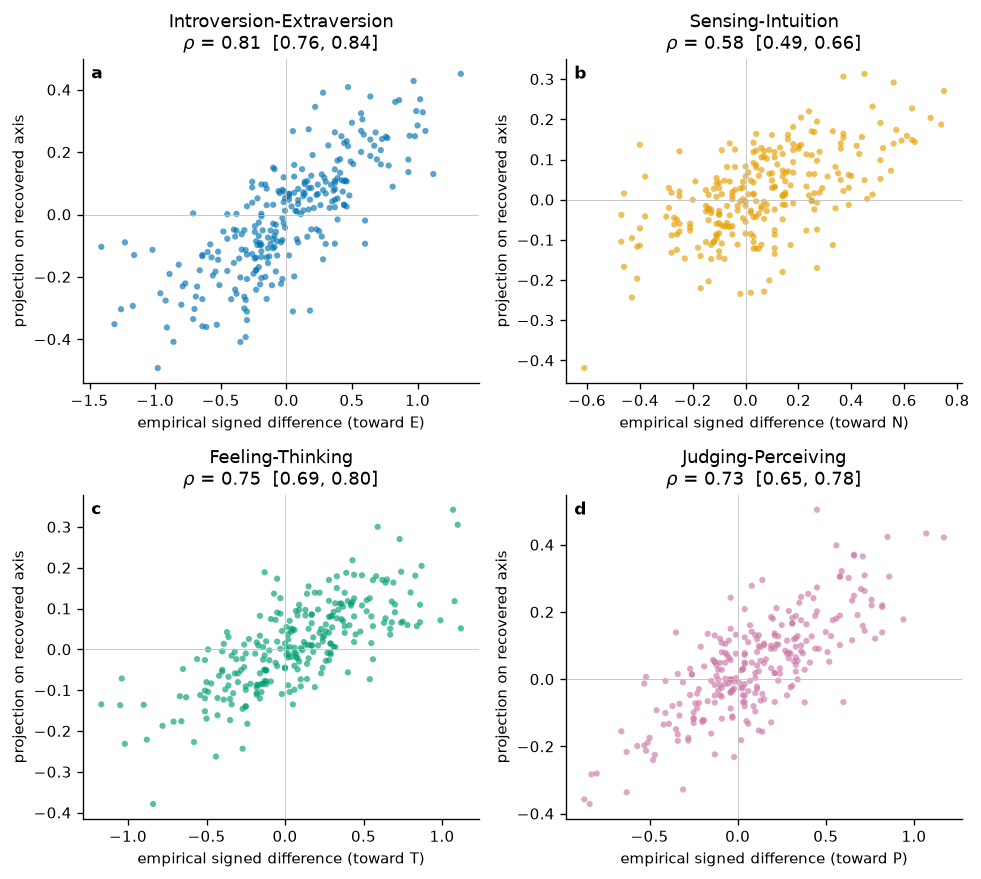

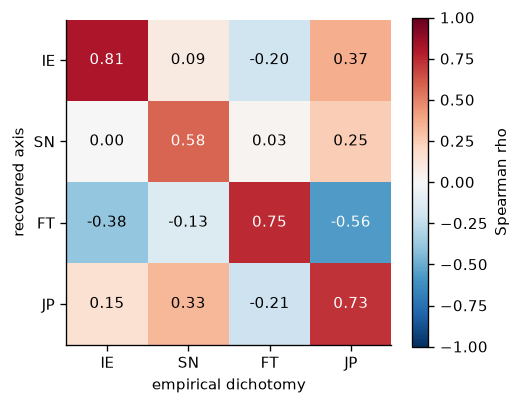

In [15]:
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})


def save_publication_figure(fig, stem):
    fig.savefig(CFG.FIG_OUT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(CFG.FIG_OUT_DIR / f"{stem}.pdf", bbox_inches="tight")


pred = VALID[PRIMARY]["pred"]


def add_panel_label(ax, label):
    ax.text(
        0.02, 0.98, label, transform=ax.transAxes,
        ha="left", va="top", fontsize=10, fontweight="bold", zorder=10,
    )


# Predicted versus empirical scatter panels
n_scales = len(SCALES)
ncols = min(2, n_scales)
nrows = int(math.ceil(n_scales / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.7 * nrows), squeeze=False)
scatter_axes = axs.ravel()
for panel_index, (ax, sc) in enumerate(zip(scatter_axes, SCALES)):
    x = screen.loc[held, f"s_{sc}"]; y = pred.loc[held, sc]
    ax.axhline(0, lw=0.5, color="0.75"); ax.axvline(0, lw=0.5, color="0.75")
    ax.scatter(x, y, s=14, alpha=0.65, color=PALETTE[sc], edgecolor="none")
    rho = VALID[PRIMARY]["convergent"].loc[sc, "spearman_rho"]
    lo = VALID[PRIMARY]["convergent"].loc[sc, "rho_ci_lo"]
    hi = VALID[PRIMARY]["convergent"].loc[sc, "rho_ci_hi"]
    ax.set_title(f"{SCALE_NAMES[sc]}\n" + rf"$\rho$ = {rho:.2f}  [{lo:.2f}, {hi:.2f}]")
    ax.set_xlabel(f"empirical signed difference (toward {POS_POLE[sc]})")
    ax.set_ylabel("projection on recovered axis")
    add_panel_label(ax, chr(ord("a") + panel_index))
for ax in scatter_axes[n_scales:]:
    ax.remove()
fig.tight_layout()
save_publication_figure(fig, "fig_validity_scatter")
plt.show()

# Convergent-discriminant association heatmap
fig, ax = plt.subplots(figsize=(4.4, 3.8))
M = VALID[PRIMARY]["rho_matrix"].to_numpy()
im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r")
tick_positions = np.arange(len(SCALES))
ax.set_xticks(tick_positions, SCALES); ax.set_yticks(tick_positions, SCALES)
ax.set_xlabel("empirical dichotomy"); ax.set_ylabel("recovered axis")
for i in range(len(SCALES)):
    for j in range(len(SCALES)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(M[i, j]) > 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.85, label="Spearman rho")
fig.tight_layout()
save_publication_figure(fig, "fig_mtmm_heatmap")
plt.show()


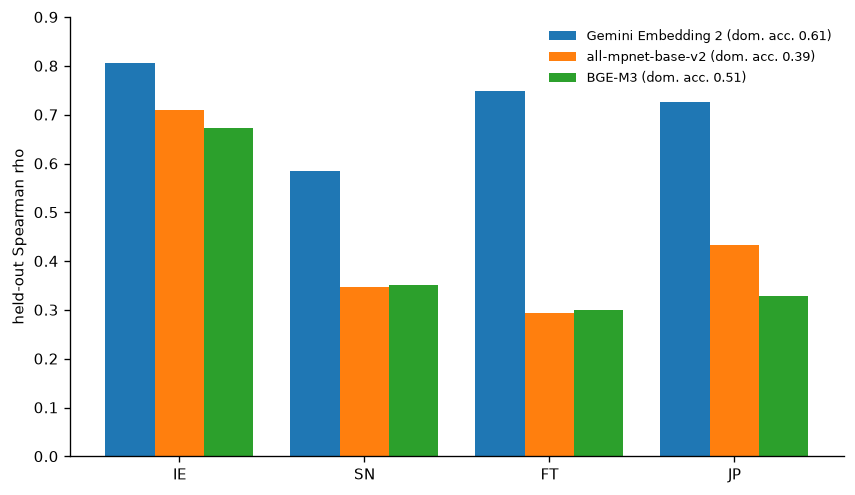

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(SCALES))
n_backends = len(ENCODER_RHOS)
width = 0.8 / n_backends
for index, (name, correlations) in enumerate(ENCODER_RHOS.items()):
    values = [correlations[scale] for scale in SCALES]
    ax.bar(
        x + (index - (n_backends - 1) / 2) * width,
        values,
        width,
        label=f"{name} (dom. acc. {ENCODER_ACCS[name]:.2f})",
    )
ax.set_xticks(x)
ax.set_xticklabels(SCALES)
ax.set_ylabel("held-out Spearman rho")
ax.set_ylim(0, 0.9)
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
save_publication_figure(fig, "fig_encoder_comparison")
plt.show()


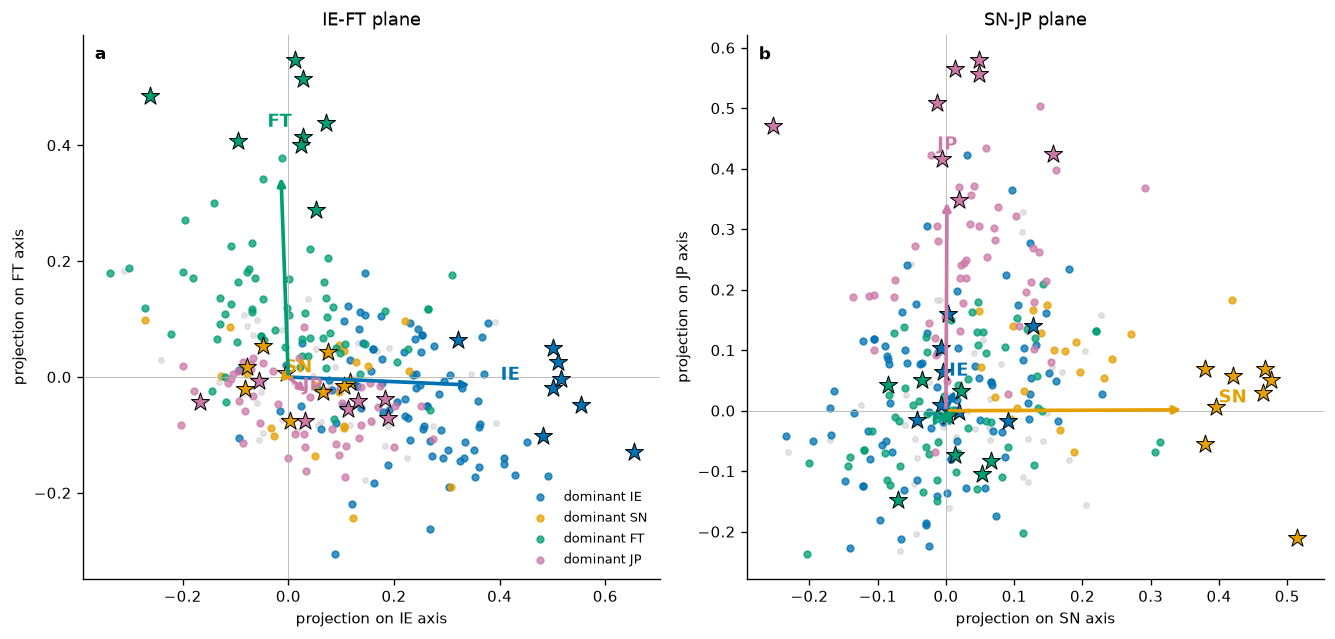

Saved fig_embedding_map


In [17]:
axis_vectors = AXES[PRIMARY]["axes"]
ELs, ERs = EMB[PRIMARY]["screen"]
differences = row_unit(ERs - ELs)
ELi, ERi = EMB[PRIMARY]["items"]
signs = items_df["sign"].to_numpy(dtype=float)[:, None]
defining_differences = row_unit((ERi - ELi) * signs)

orientation = np.ones(len(screen), dtype=float)
unique_empirical_dominance = held_array & (~emp_tie)
for index in np.where(unique_empirical_dominance)[0]:
    dominant_scale = emp_lab[index]
    empirical_value = float(screen.loc[index, f"s_{dominant_scale}"])
    orientation[index] = 1.0 if empirical_value >= 0 else -1.0

fig, axs = plt.subplots(1, len(EMBED_PLANES), figsize=(5.6 * len(EMBED_PLANES), 5.4), squeeze=False)
plane_axes = axs.ravel()
for panel_index, (axis_plot, (axis_a, axis_b)) in enumerate(zip(plane_axes, EMBED_PLANES)):
    X = (differences @ axis_vectors[axis_a]) * orientation
    Y = (differences @ axis_vectors[axis_b]) * orientation
    non_clear = held_array & (~clear)
    axis_plot.scatter(X[non_clear], Y[non_clear], s=10, color="0.82", alpha=0.6)
    for scale in SCALES:
        mask = clear & (emp_lab == scale)
        axis_plot.scatter(
            X[mask], Y[mask], s=16, alpha=0.75, color=PALETTE[scale], label="dominant " + scale
        )

    Xi = defining_differences @ axis_vectors[axis_a]
    Yi = defining_differences @ axis_vectors[axis_b]
    for scale in SCALES:
        mask = (items_df["scale"] == scale).to_numpy()
        axis_plot.scatter(
            Xi[mask], Yi[mask], marker="*", s=130, color=PALETTE[scale],
            edgecolor="black", linewidth=0.6, zorder=5,
        )
    for scale in SCALES:
        vx = float(axis_vectors[scale] @ axis_vectors[axis_a])
        vy = float(axis_vectors[scale] @ axis_vectors[axis_b])
        axis_plot.annotate(
            "", xy=(vx * 0.35, vy * 0.35), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE[scale], lw=2.2), zorder=6,
        )
        axis_plot.text(
            vx * 0.42, vy * 0.42 + 0.012, scale, color=PALETTE[scale],
            fontsize=11, fontweight="bold", ha="center", zorder=6,
        )
    axis_plot.axhline(0, lw=0.5, color="0.7")
    axis_plot.axvline(0, lw=0.5, color="0.7")
    axis_plot.set_xlabel("projection on " + axis_a + " axis")
    axis_plot.set_ylabel("projection on " + axis_b + " axis")
    axis_plot.set_title(axis_a + "-" + axis_b + " plane")
    add_panel_label(axis_plot, chr(ord("a") + panel_index))
    axis_plot.spines["top"].set_visible(False)
    axis_plot.spines["right"].set_visible(False)
plane_axes[0].legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
save_publication_figure(fig, "fig_embedding_map")
plt.show()
print("Saved fig_embedding_map")


## 15. Export compact result summaries

In [18]:
primary_scale_rows = []
for scale in SCALES:
    convergent = VALID[PRIMARY]["convergent"].loc[scale]
    alignments = np.asarray(AXES[PRIMARY]["align"][scale], dtype=float)
    primary_scale_rows.append({
        "record_type": "scale",
        "scale": scale,
        "spearman_rho": float(convergent["spearman_rho"]),
        "spearman_p": float(convergent["spearman_p"]),
        "spearman_p_holm": float(convergent["spearman_p_holm"]),
        "rho_ci_lo": float(convergent["rho_ci_lo"]),
        "rho_ci_hi": float(convergent["rho_ci_hi"]),
        "pearson_r": float(convergent["pearson_r"]),
        "pearson_p": float(convergent["pearson_p"]),
        "pair_alignment_min": float(alignments.min()),
        "loo_min_cosine": float(AXES[PRIMARY]["loo"][scale].min()),
        "axis_bootstrap_q025_cosine": float(
            AXIS_BOOTSTRAP_SUMMARY[PRIMARY].loc[scale, "q025"]
        ),
    })

primary_overall = {
    "record_type": "overall",
    "scale": "ALL",
    "n_screen": int(len(screen)),
    "n_held_out": int(held.sum()),
    "n_clear_dominance": int(clear.sum()),
    "classification_accuracy": float(CLS[PRIMARY]["acc"]),
    "permutation_null_mean": float(CLS[PRIMARY]["null_mean"]),
    "permutation_exceedances": int(CLS[PRIMARY]["exceedances"]),
    "permutation_p": float(CLS[PRIMARY]["p_perm"]),
    "standardised_projection_accuracy": float(ZCLS["acc"]),
    "g2_exceed_count": int(G2_EXCEED_COUNT),
    "g2_directional_cells": int(G2_TOTAL),
    "g2_max_excess": float(G2_MAX_EXCESS),
    "partial_max_abs": float(PARTIAL_MAX_ABS),
    "gram_max_off_diagonal": float(GRAM_MAX_OFF),
    "template_min_cosine": float(TEMPLATE_MIN_COS),
    "reversed_pair_mean_cosine": float(REV_SUMMARY["mean"]),
}

PRIMARY_RESULTS = pd.concat(
    [pd.DataFrame(primary_scale_rows), pd.DataFrame([primary_overall])],
    ignore_index=True,
    sort=False,
)
PRIMARY_RESULTS.to_csv(CFG.OUT_DIR / "results_primary.csv", index=False)

replication_rows = []
for backend, label in BACKENDS:
    comparison = AXES[backend]["llm_comparison"]
    for scale in SCALES:
        replication_rows.append({
            "backend": backend,
            "backend_label": label,
            "is_primary": backend == PRIMARY,
            "scale": scale,
            "criterion_spearman": float(
                VALID[backend]["convergent"].loc[scale, "spearman_rho"]
            ),
            "classification_accuracy": float(CLS[backend]["acc"]),
            "permutation_null_mean": float(CLS[backend]["null_mean"]),
            "permutation_p": float(CLS[backend]["p_perm"]),
            "axis_bootstrap_q025_cosine": float(
                AXIS_BOOTSTRAP_SUMMARY[backend].loc[scale, "q025"]
            ),
            "generated_axis_cosine": float(
                comparison.loc[scale, "cos_llm_vs_item_axis"]
            ),
            "generated_prediction_convergence": float(
                comparison.loc[scale, "prediction_convergence"]
            ),
            "generated_axis_criterion_spearman": float(
                comparison.loc[scale, "llm_axis_spearman"]
            ),
            "generated_pairs_accepted": int(
                LLM_AUDIT_SUMMARY.loc[scale, "accepted"]
            ),
            "generated_pairs_discarded": int(
                LLM_AUDIT_SUMMARY.loc[scale, "discarded"]
            ),
            "generated_pairs_reversed_corrected": int(
                LLM_AUDIT_SUMMARY.loc[scale, "reversed_corrected"]
            ),
            "generated_pairs_duplicates_discarded": int(
                LLM_AUDIT_SUMMARY.loc[scale, "duplicates_discarded"]
            ),
        })

REPLICATION_RESULTS = pd.DataFrame(replication_rows)
REPLICATION_RESULTS.to_csv(CFG.OUT_DIR / "results_replication.csv", index=False)

print("Saved compact result summaries: results_primary.csv and results_replication.csv")
display(PRIMARY_RESULTS.round(3))
display(REPLICATION_RESULTS.round(3))

Saved compact result summaries: results_primary.csv and results_replication.csv


,record_type,scale,spearman_rho,spearman_p,spearman_p_holm,rho_ci_lo,rho_ci_hi,pearson_r,pearson_p,pair_alignment_min,...,permutation_exceedances,permutation_p,standardised_projection_accuracy,g2_exceed_count,g2_directional_cells,g2_max_excess,partial_max_abs,gram_max_off_diagonal,template_min_cosine,reversed_pair_mean_cosine
0,scale,IE,0.805,0.0,0.0,0.757,0.845,0.783,0.0,0.321,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,scale,SN,0.584,0.0,0.0,0.490,0.664,0.598,0.0,0.380,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,scale,FT,0.749,0.0,0.0,0.688,0.800,0.742,0.0,0.288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,scale,JP,0.726,0.0,0.0,0.654,0.784,0.772,0.0,0.348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,overall,ALL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.577,5.0,12.0,0.117,0.348,0.11,0.911,1.0


,backend,backend_label,is_primary,scale,criterion_spearman,classification_accuracy,permutation_null_mean,permutation_p,axis_bootstrap_q025_cosine,generated_axis_cosine,generated_prediction_convergence,generated_axis_criterion_spearman,generated_pairs_accepted,generated_pairs_discarded,generated_pairs_reversed_corrected,generated_pairs_duplicates_discarded
0,gemini,Gemini Embedding 2,True,IE,0.805,0.614,0.289,0.0,0.733,0.709,0.954,0.806,40,0,0,0
1,gemini,Gemini Embedding 2,True,SN,0.584,0.614,0.289,0.0,0.672,0.449,0.468,0.628,40,0,0,0
2,gemini,Gemini Embedding 2,True,FT,0.749,0.614,0.289,0.0,0.663,0.334,0.826,0.742,40,0,0,0
3,gemini,Gemini Embedding 2,True,JP,0.726,0.614,0.289,0.0,0.712,0.570,0.721,0.822,40,0,0,0
4,mpnet,all-mpnet-base-v2,False,IE,0.709,0.391,0.281,0.0,0.665,0.616,0.911,0.723,40,0,0,0
5,mpnet,all-mpnet-base-v2,False,SN,0.347,0.391,0.281,0.0,0.606,0.385,0.520,0.510,40,0,0,0
6,mpnet,all-mpnet-base-v2,False,FT,0.294,0.391,0.281,0.0,0.644,0.209,0.468,0.532,40,0,0,0
7,mpnet,all-mpnet-base-v2,False,JP,0.433,0.391,0.281,0.0,0.676,0.238,0.052,0.479,40,0,0,0
8,bge_m3,BGE-M3,False,IE,0.673,0.512,0.294,0.0,0.696,0.728,0.961,0.684,40,0,0,0
9,bge_m3,BGE-M3,False,SN,0.351,0.512,0.294,0.0,0.605,0.352,0.214,0.440,40,0,0,0


## 16. LaTeX result macros

This cell writes the numerical values used by the manuscript to `outputs/results_macros.tex`.


In [19]:
def texnum(value, decimals=2):
    return f"{float(value):.{decimals}f}"


def texsci(value, significant_digits=2):
    value = float(value)
    if value == 0:
        return "0"
    exponent = int(math.floor(math.log10(abs(value))))
    coefficient = value / (10 ** exponent)
    decimals = max(significant_digits - 1, 0)
    return f"{coefficient:.{decimals}f}\\times 10^{{{exponent}}}"


def tex_date_from_iso(value):
    timestamp = pd.Timestamp(value)
    return f"{timestamp.day}~{timestamp.strftime('%B')}~{timestamp.year}"


def textrim(value, decimals=3):
    return f"{float(value):.{decimals}f}".rstrip("0").rstrip(".")


if REV_SUMMARY["n"] == 0:
    raise RuntimeError("The manuscript requires the reversed-pair implementation check, but no pairs were found.")
if "llm_comparison" not in AXES[PRIMARY]:
    raise RuntimeError("The manuscript requires the generated-contrast arm, but it was not completed.")

MACROS = {}


def add_macro(name, value):
    if name in MACROS:
        raise KeyError(f"Duplicate LaTeX macro: {name}")
    MACROS[name] = str(value)


# Design and provenance
add_macro("nDefining", INSTRUMENT_SUMMARY["n_defining"])
add_macro("nScales", INSTRUMENT_SUMMARY["n_scales"])
add_macro("nDefPerScale", INSTRUMENT_SUMMARY["n_per_scale"])
add_macro("nLOOPerScale", INSTRUMENT_SUMMARY["n_per_scale"] - 1)
add_macro("nRawScreen", PARSE_SUMMARY["raw_rows"])
add_macro("nMalformedScreen", PARSE_SUMMARY["malformed_rows"])
add_macro("nExactDuplicatesRemoved", PARSE_SUMMARY["exact_duplicates_removed"])
add_macro("nAnchorCollisionRows", PARSE_SUMMARY["anchor_collision_rows"])
add_macro("nCollisionExcluded", COLLISION_EXCLUDED_HELD_COUNT)
add_macro("nDefiningSourceRowsExcluded", DEFINING_SOURCE_ROWS_EXCLUDED_COUNT)
add_macro("nDefiningSourceVariants", DEFINING_SOURCE_VARIANT_COUNT)
add_macro("nScreen", len(screen))
add_macro("nAnalysisEligible", int(screen["analysis_eligible"].sum()))
add_macro("nHeld", int(held.sum()))
add_macro("nThresholdEligible", THRESHOLD_ELIGIBLE_COUNT)
add_macro("nDominanceTies", DOMINANCE_TIE_COUNT)
add_macro("nClear", int(clear.sum()))
add_macro("embDim", EMB_DIMS[PRIMARY])
add_macro("nBoot", CFG.N_BOOT)
add_macro("nPerm", CFG.N_PERM)
add_macro("permDenom", PERM_SUMMARY["denominator"])
add_macro("permResolution", texsci(PERM_SUMMARY["resolution"]))
add_macro("dominanceMin", texnum(CFG.DOMINANCE_MIN))
add_macro("dominanceTieTol", texsci(CFG.DOMINANCE_TIE_ATOL))
add_macro("nGenPairs", CFG.N_PAIRS_PER_DICHOTOMY)
add_macro("nEncoders", len(BACKENDS))
add_macro("nOpenEncoders", max(len(BACKENDS) - int(PRIMARY == "gemini"), 0))
add_macro("ciLevelPct", int(round(100 * CFG.CI_LEVEL)))
add_macro("ciLowerPct", textrim(100 * (1 - CFG.CI_LEVEL) / 2, 2))
add_macro("sourceSampleN", f"{SOURCE_REPORTED['development_sample_n']:,}")
add_macro("sourceCandidatePoolN", SOURCE_REPORTED["candidate_pool_n"])
add_macro("sourceIntermediateN", SOURCE_REPORTED["retained_intermediate_n"])
add_macro("sourceIntermediatePerScale", SOURCE_REPORTED["retained_intermediate_per_scale"])
add_macro("sourceMinGroupN", SOURCE_REPORTED["minimum_group_n_approx"])
add_macro("sourceCriterionCIPct", SOURCE_REPORTED["criterion_ci_percent"])
add_macro("mpnetParamM", CFG.MPNET_PARAMETER_MILLIONS)
add_macro("bgeParamM", CFG.BGE_PARAMETER_MILLIONS)
add_macro("sourceAccessDate", tex_date_from_iso(SOURCE_PROVENANCE["retrieved_utc"]))
add_macro("analysisRunDate", tex_date_from_iso(CFG.RUN_STARTED_UTC))

# Primary convergent validity
add_macro("alphaLevel", texnum(CFG.ALPHA))
for scale in SCALES:
    add_macro(f"rho{scale}", texnum(PRIM_CONV.loc[scale, "spearman_rho"]))
    add_macro(f"rho{scale}lo", texnum(PRIM_CONV.loc[scale, "rho_ci_lo"]))
    add_macro(f"rho{scale}hi", texnum(PRIM_CONV.loc[scale, "rho_ci_hi"]))
    add_macro(f"pearson{scale}", texnum(PRIM_CONV.loc[scale, "pearson_r"]))
    add_macro(f"pSpearman{scale}", texsci(PRIM_CONV.loc[scale, "spearman_p"], 3))
    add_macro(f"pSpearman{scale}Holm", texsci(PRIM_CONV.loc[scale, "spearman_p_holm"], 3))

# Criterion range and convergent--discriminant diagnostics
add_macro("critMeanAbsSN", texnum(CRIT_RANGE["sn_mean_abs"]))
add_macro("critMeanAbsOtherMin", texnum(CRIT_RANGE["other_min"]))
add_macro("critMeanAbsOtherMax", texnum(CRIT_RANGE["other_max"]))
add_macro("nSNDom", DOM_COUNTS["SN"])
add_macro("mtmmMaxOff", texnum(MTMM_MAX_OFF))
add_macro("mtmmMeanOff", texnum(MTMM_MEAN_OFF))
add_macro("mtmmRowDominance", MTMM_ROW_DOMINANCE)
add_macro("mtmmColumnDominance", MTMM_COLUMN_DOMINANCE)
add_macro("mtmmFTJP", texnum(MTMM_SELECTED[("FT", "JP")]))
add_macro("mtmmIEJP", texnum(MTMM_SELECTED[("IE", "JP")]))
add_macro("mtmmJPSN", texnum(MTMM_SELECTED[("JP", "SN")]))
add_macro("critIEFT", texnum(CRIT_SELECTED[("IE", "FT")]))
add_macro("critIEJP", texnum(CRIT_SELECTED[("IE", "JP")]))
add_macro("critSNJP", texnum(CRIT_SELECTED[("SN", "JP")]))
add_macro("critFTJP", texnum(CRIT_SELECTED[("FT", "JP")]))
add_macro("critOtherMax", texnum(CRIT_OTHER_MAX))
add_macro("partFTJP", texnum(PARTIAL_CROSS[("FT", "JP")]))
add_macro("partIEJP", texnum(PARTIAL_CROSS[("IE", "JP")]))
add_macro("partJPSN", texnum(PARTIAL_CROSS[("JP", "SN")]))
add_macro("gTwoExceedCount", G2_EXCEED_COUNT)
add_macro("gTwoDirectionalCells", G2_TOTAL)
add_macro("gTwoMaxExcess", texnum(G2_MAX_EXCESS))
add_macro("partialMaxOff", texnum(PARTIAL_MAX_ABS))

# Classification and geometry
add_macro("clsAcc", texnum(CLS[PRIMARY]["acc"], 3))
add_macro("clsNull", texnum(CLS[PRIMARY]["null_mean"], 3))
add_macro("clsPerm", texsci(CLS[PRIMARY]["p_perm"], 5))
add_macro("clsExceedances", CLS[PRIMARY]["exceedances"])
add_macro("nPredTies", CLS[PRIMARY]["pred_tie_count"])
add_macro("zAcc", texnum(ZCLS["acc"], 3))
add_macro("nZPredTies", ZCLS["pred_tie_count"])
for scale in SCALES:
    add_macro(f"loo{scale}", texnum(LOO_MIN[scale], 3))
    add_macro(f"axisBoot{scale}Lo", texnum(AXIS_BOOT_PRIMARY_Q025[scale], 3))
add_macro("axisBootMinLo", texnum(AXIS_BOOT_MIN_Q025, 3))
add_macro("pairAlignMin", texnum(PAIR_ALIGNMENT_MIN, 3))
add_macro("nNegativeAlign", NEGATIVE_ALIGNMENT_COUNT)
add_macro("misclassScale", MISCLASS_SCALE)
add_macro("misclassErrors", MISCLASS_ERRORS)
add_macro("gramMaxOff", texnum(GRAM_MAX_OFF))
add_macro("gramOtherMaxOff", texnum(GRAM_OTHER_MAX_OFF))
add_macro("inplaneMaxOff", texnum(INPLANE_MAX_OFF))
add_macro("nRevTwin", REV_SUMMARY["n"])
add_macro("revCosMean", texnum(REV_SUMMARY["mean"]))
add_macro("templMinCos", texnum(TEMPLATE_MIN_COS))

# Encoder replication
for scale in SCALES:
    add_macro(f"rhoSec{scale}", texnum(VALID["mpnet"]["convergent"].loc[scale, "spearman_rho"]))
    add_macro(f"rhoTrd{scale}", texnum(VALID["bge_m3"]["convergent"].loc[scale, "spearman_rho"]))
add_macro("accSec", texnum(CLS["mpnet"]["acc"], 3))
add_macro("nullSec", texnum(CLS["mpnet"]["null_mean"], 3))
add_macro("permSec", texsci(CLS["mpnet"]["p_perm"], 5))
add_macro("accTrd", texnum(CLS["bge_m3"]["acc"], 3))
add_macro("nullTrd", texnum(CLS["bge_m3"]["null_mean"], 3))
add_macro("permTrd", texsci(CLS["bge_m3"]["p_perm"], 5))
for scale in SCALES:
    add_macro(f"xEnc{scale}Min", texnum(XCORR_RANGE[scale][0]))
    add_macro(f"xEnc{scale}Max", texnum(XCORR_RANGE[scale][1]))
add_macro("primaryRhoMin", texnum(PRIMARY_RHO_RANGE[0]))
add_macro("primaryRhoMax", texnum(PRIMARY_RHO_RANGE[1]))
add_macro("openRhoMin", texnum(OPEN_RHO_RANGE[0]))
add_macro("openRhoMax", texnum(OPEN_RHO_RANGE[1]))

# Generated-contrast arm
comparison = AXES[PRIMARY]["llm_comparison"]
for scale in SCALES:
    add_macro(f"convLLM{scale}", texnum(comparison.loc[scale, "cos_llm_vs_item_axis"]))
    add_macro(f"predConv{scale}", texnum(comparison.loc[scale, "prediction_convergence"]))
    add_macro(f"rhoLLM{scale}", texnum(comparison.loc[scale, "llm_axis_spearman"]))
    add_macro(f"genAccepted{scale}", int(LLM_AUDIT_SUMMARY.loc[scale, "accepted"]))
    add_macro(f"genDiscarded{scale}", int(LLM_AUDIT_SUMMARY.loc[scale, "discarded"]))
    add_macro(f"genReversed{scale}", int(LLM_AUDIT_SUMMARY.loc[scale, "reversed_corrected"]))
    add_macro(f"genDuplicate{scale}", int(LLM_AUDIT_SUMMARY.loc[scale, "duplicates_discarded"]))

macro_lines = ["% Auto-generated by the OEJTS embedding-axis analysis."]
for name, value in MACROS.items():
    macro_lines.append(f"\\newcommand{{\\{name}}}{{{value}}}")
macro_block = "\n".join(macro_lines) + "\n"
macro_path = CFG.OUT_DIR / "results_macros.tex"
macro_path.write_text(macro_block, encoding="utf-8")

print(macro_block)
print("Saved:", macro_path)


% Auto-generated by the OEJTS embedding-axis analysis.
\newcommand{\nDefining}{32}
\newcommand{\nScales}{4}
\newcommand{\nDefPerScale}{8}
\newcommand{\nLOOPerScale}{7}
\newcommand{\nRawScreen}{298}
\newcommand{\nMalformedScreen}{1}
\newcommand{\nExactDuplicatesRemoved}{0}
\newcommand{\nAnchorCollisionRows}{2}
\newcommand{\nCollisionExcluded}{2}
\newcommand{\nDefiningSourceRowsExcluded}{35}
\newcommand{\nDefiningSourceVariants}{3}
\newcommand{\nScreen}{297}
\newcommand{\nAnalysisEligible}{295}
\newcommand{\nHeld}{260}
\newcommand{\nThresholdEligible}{217}
\newcommand{\nDominanceTies}{2}
\newcommand{\nClear}{215}
\newcommand{\embDim}{3072}
\newcommand{\nBoot}{2000}
\newcommand{\nPerm}{5000}
\newcommand{\permDenom}{5001}
\newcommand{\permResolution}{2.0\times 10^{-4}}
\newcommand{\dominanceMin}{0.35}
\newcommand{\dominanceTieTol}{1.0\times 10^{-12}}
\newcommand{\nGenPairs}{40}
\newcommand{\nEncoders}{3}
\newcommand{\nOpenEncoders}{2}
\newcommand{\ciLevelPct}{95}
\newcommand{\ciLowerPct}{2